# Module 2 - Regression

## Problem Framing

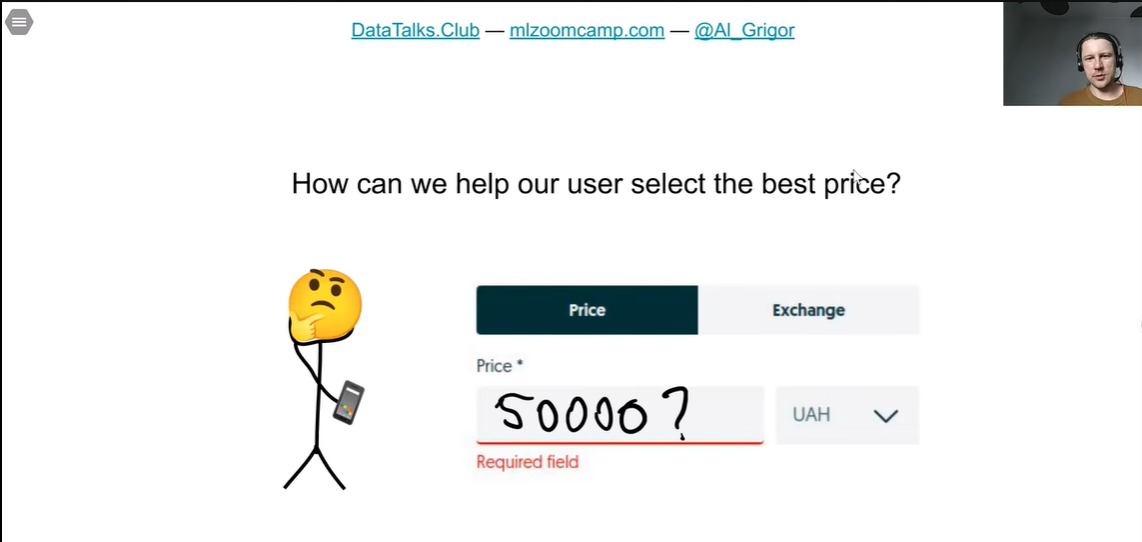

### Project Plan

1. Prepare data and EDA (Exploratory Data Analysis)
2. Use linear regression for predicting the price
3. Understand the internals of linear regression
4. Evaluating the model with RMSE (Root Mean Squared Error)
5. Feature engineering
6. Regularization
7. Use the model

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pprint import pprint

np.set_printoptions(suppress=True)

## Data Preparation

### Download the dataset

`wget` is a way for downloading files using the command line

In [2]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv'

# -nc means "no clobber": wget skips the download if the file already exists
!wget -nc $data

File ‘data.csv’ already there; not retrieving.



### Load the dataset

`MSRP` is the prediction target

In [3]:
df = pd.read_csv('data.csv')

# Preview first few rows
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


### Cleaning the data

In [4]:
# Column names are inconsistent (mixed case, spaces)
# We need to standardize these
df.columns

Index(['Make', 'Model', 'Year', 'Engine Fuel Type', 'Engine HP',
       'Engine Cylinders', 'Transmission Type', 'Driven_Wheels',
       'Number of Doors', 'Market Category', 'Vehicle Size', 'Vehicle Style',
       'highway MPG', 'city mpg', 'Popularity', 'MSRP'],
      dtype='str')

In [5]:
# Turn column names into snake case (lowercase, underscores instead of spaces)
df.columns = df.columns.str.lower().str.replace(' ', '_')

df.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity', 'msrp'],
      dtype='str')

In [6]:
# Looking at the values of our categorical columns, we can see that they're inconsistent as well
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [7]:
# First, we need to identify the str columns
df.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

In [8]:
# Get the list of str columns
str_columns = list(df.dtypes[df.dtypes == 'str'].index)

str_columns

['make',
 'model',
 'engine_fuel_type',
 'transmission_type',
 'driven_wheels',
 'market_category',
 'vehicle_size',
 'vehicle_style']

In [9]:
# Automate the process of standardizing the values in the str columns
for col in str_columns:
    df[col] = df[col].str.lower().str.replace(' ', '_')

df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


## Exploratory Data Analysis (EDA)

### Preview data

In [10]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


### Summary info

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   make               11914 non-null  str    
 1   model              11914 non-null  str    
 2   year               11914 non-null  int64  
 3   engine_fuel_type   11911 non-null  str    
 4   engine_hp          11845 non-null  float64
 5   engine_cylinders   11884 non-null  float64
 6   transmission_type  11914 non-null  str    
 7   driven_wheels      11914 non-null  str    
 8   number_of_doors    11908 non-null  float64
 9   market_category    8172 non-null   str    
 10  vehicle_size       11914 non-null  str    
 11  vehicle_style      11914 non-null  str    
 12  highway_mpg        11914 non-null  int64  
 13  city_mpg           11914 non-null  int64  
 14  popularity         11914 non-null  int64  
 15  msrp               11914 non-null  int64  
dtypes: float64(3), int64(5), str(8)
m

### Unique values per column

In [12]:
# Check unique values per column
for col in df.columns:
    print(f'Column: {col}')
    print(f'Unique values: {df[col].nunique()}')
    print(f'Sample values: {df[col].unique()[:5].tolist()}')
    print()

Column: make
Unique values: 48
Sample values: ['bmw', 'audi', 'fiat', 'mercedes-benz', 'chrysler']

Column: model
Unique values: 914
Sample values: ['1_series_m', '1_series', '100', '124_spider', '190-class']

Column: year
Unique values: 28
Sample values: [2011, 2012, 2013, 1992, 1993]

Column: engine_fuel_type
Unique values: 10
Sample values: ['premium_unleaded_(required)', 'regular_unleaded', 'premium_unleaded_(recommended)', 'flex-fuel_(unleaded/e85)', 'diesel']

Column: engine_hp
Unique values: 356
Sample values: [335.0, 300.0, 230.0, 320.0, 172.0]

Column: engine_cylinders
Unique values: 9
Sample values: [6.0, 4.0, 5.0, 8.0, 12.0]

Column: transmission_type
Unique values: 5
Sample values: ['manual', 'automatic', 'automated_manual', 'direct_drive', 'unknown']

Column: driven_wheels
Unique values: 4
Sample values: ['rear_wheel_drive', 'front_wheel_drive', 'all_wheel_drive', 'four_wheel_drive']

Column: number_of_doors
Unique values: 3
Sample values: [2.0, 4.0, 3.0, nan]

Column: mar

### Distribution of the target (MSRP)

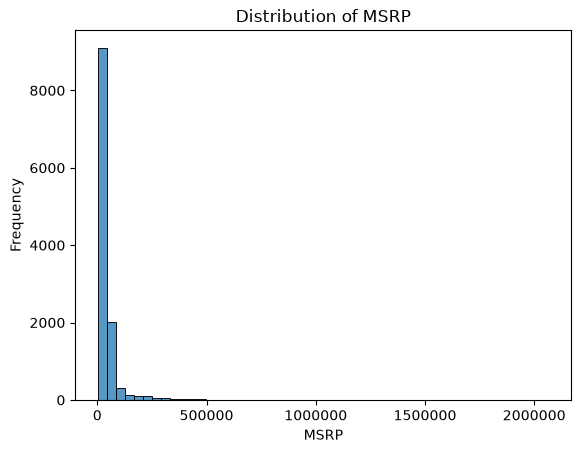

In [13]:
sns.histplot(data=df, x='msrp', bins=50)

plt.ticklabel_format(style='plain', axis='x') # Prevent scientific notation on x-axis
plt.title('Distribution of MSRP')
plt.xlabel('MSRP')
plt.ylabel('Frequency')
plt.show()

### Long-tail distribution

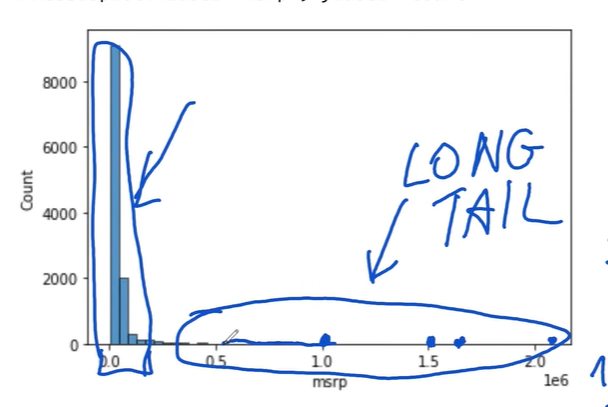

Most of the data is concentrated on the left side. This means most of our car prices are on the lower end of the range.

However, there are a few values on the right side, causing something called a **long-tailed distribution**. This represents very expensive luxury/sports cars.

In [14]:
df.nlargest(10, 'msrp')[['make', 'model', 'msrp']]

,make,model,msrp
11362,bugatti,veyron_16.4,2065902
11364,bugatti,veyron_16.4,1705769
8486,lamborghini,reventon,1500000
11363,bugatti,veyron_16.4,1500000
6351,maybach,landaulet,1382750
6350,maybach,landaulet,1380000
4024,ferrari,enzo,643330
1622,lamborghini,aventador,548800
1626,lamborghini,aventador,548800
1629,lamborghini,aventador,535500


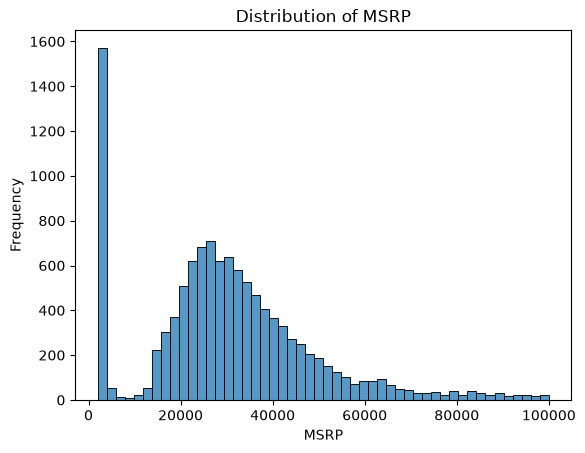

In [15]:
sns.histplot(df[df['msrp'] < 100000], x='msrp', bins=50)
plt.title('Distribution of MSRP')
plt.xlabel('MSRP')
plt.ylabel('Frequency')
plt.show()

Zoomed in on cars under $100k to see the shape of "normal" cars. The few luxury cars above $100k (Bugatti, Lamborghini, Maybach, Ferrari) stretch the full chart, so they are hidden here.

- Most cars cost **$20k to $40k**, with a peak near **$25k to $30k**.
- The distribution is still **right-skewed**.
- There is a **spike near $2,000** (about 1,500 cars). New cars don't cost this little, so it is likely a placeholder value. **To check.**

### Apply logarithmic transformation

**IMPORTANT:** 

This distribution is not good for our model. A few very expensive cars would dominate the fit, so the model would predict normal cars worse.

The solution is to apply a **logarithmic transformation** to reduce the long tail.

Log doesn't work on 0, so we add 1 to every price first. NumPy does both steps in one function: `np.log1p()`.

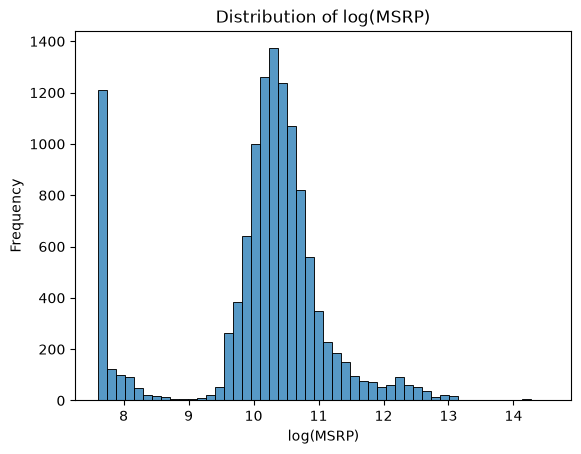

In [16]:
msrp_log = np.log1p(df['msrp'])

sns.histplot(msrp_log, bins=50)
plt.title('Distribution of log(MSRP)')
plt.xlabel('log(MSRP)')
plt.ylabel('Frequency')
plt.show()

After the log transformation, the distribution now looks like a **bell curve of the normal distribution**.

Linear regression works better when the target resembles a normal distribution.

### Spot Missing Values

In [17]:
# Check missing values across columns
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

## Validation Framework

We will need to split up our dataset into 3 parts:

- Training
- Validation
- Test

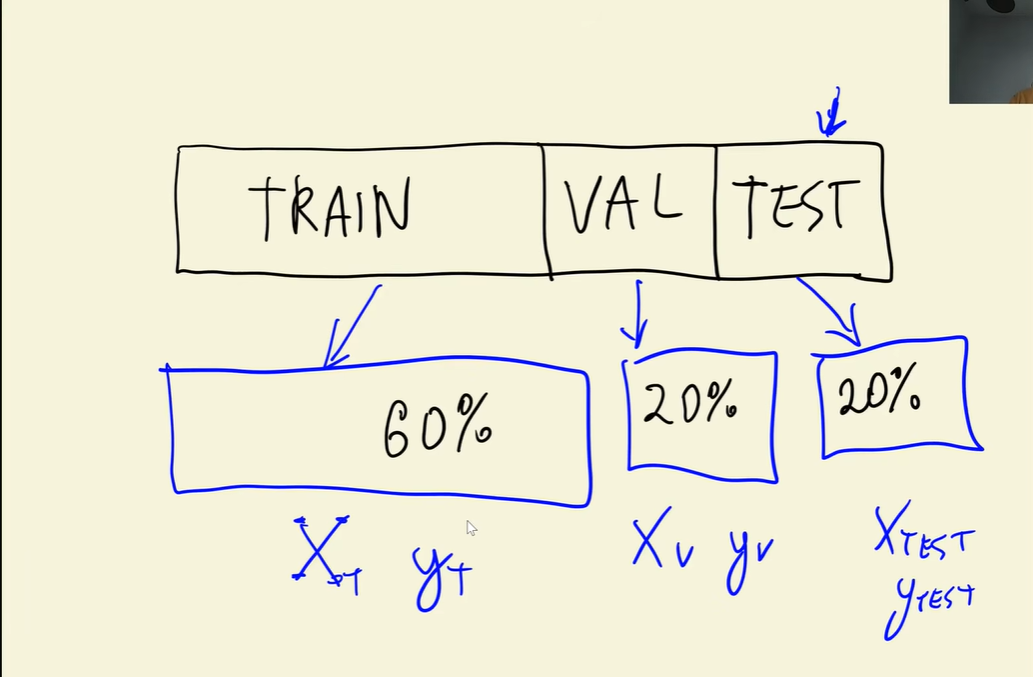

### Compute how many records to include in each split

In [18]:
n = len(df) # Total number of rows in the dataset

n_val = int(n * 0.2) # 20% for validation
n_test = int(n * 0.2) # 20% for testing
n_train = n - n_val - n_test # The rest for training (60%)

print(f'full={n}, train={n_train}, val={n_val}, test={n_test}')

full=11914, train=7150, val=2382, test=2382


### Split the data

In [19]:
df_train = df[:n_train].copy()

print(f'Train set shape: {df_train.shape}')

Train set shape: (7150, 16)


In [20]:
df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


In [21]:
df_val = df[n_train:n_train+n_val].copy()

print(f'Validation set shape: {df_val.shape}')

Validation set shape: (2382, 16)


In [22]:
df_val.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
7150,lincoln,navigator,2015,regular_unleaded,365.0,6.0,automatic,rear_wheel_drive,4.0,luxury,large,4dr_suv,20,15,61,63645
7151,lincoln,navigator,2016,regular_unleaded,380.0,6.0,automatic,rear_wheel_drive,4.0,luxury,large,4dr_suv,22,16,61,63195
7152,lincoln,navigator,2016,regular_unleaded,380.0,6.0,automatic,four_wheel_drive,4.0,luxury,large,4dr_suv,19,15,61,76650
7153,lincoln,navigator,2016,regular_unleaded,380.0,6.0,automatic,four_wheel_drive,4.0,luxury,large,4dr_suv,19,15,61,69135
7154,lincoln,navigator,2016,regular_unleaded,380.0,6.0,automatic,rear_wheel_drive,4.0,luxury,large,4dr_suv,20,15,61,65560


In [23]:
df_test = df[n_val:n_val+n_test].copy()

print(f'Test set shape: {df_test.shape}')

Test set shape: (2382, 16)


In [24]:
df_test.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
2382,porsche,cayenne,2017,premium_unleaded_(required),570.0,8.0,automatic,all_wheel_drive,4.0,"crossover,luxury,high-performance",midsize,4dr_suv,21,14,1715,159600
2383,porsche,cayenne,2017,premium_unleaded_(required),420.0,6.0,automatic,all_wheel_drive,4.0,"crossover,luxury,performance",midsize,4dr_suv,24,17,1715,76200
2384,porsche,cayman_s,2006,premium_unleaded_(required),295.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,26,18,1715,58900
2385,porsche,cayman,2014,premium_unleaded_(required),275.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,30,20,1715,52600
2386,porsche,cayman,2014,premium_unleaded_(required),325.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,1715,63800


### Shuffle the data

Now we have a problem: the data is sequential (e.g., ome car makes could only belong in one split but be absent in the others)

The solution is to **shuffle our dataset**.

In [25]:
# Step 1: Create indexes
idx = np.arange(n)

idx

array([    0,     1,     2, ..., 11911, 11912, 11913], shape=(11914,))

In [26]:
# Step 2: Set the random seed for reproducibility
np.random.seed(2)

In [27]:
# Step 3: Shuffle the indexes
np.random.shuffle(idx)

idx

array([2735, 6720, 5878, ..., 6637, 2575, 7336], shape=(11914,))

In [28]:
df_train = df.iloc[idx[:n_train]].copy()

print(f'Train set shape: {df_train.shape}')

Train set shape: (7150, 16)


In [29]:
df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
2735,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,14410
6720,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
5878,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
11190,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,2000
4554,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260


In [30]:
df_val = df.iloc[idx[n_train:n_train+n_val]].copy()

print(f'Validation set shape: {df_val.shape}')

Validation set shape: (2382, 16)


In [31]:
df_val.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
2779,chevrolet,colorado,2015,regular_unleaded,200.0,4.0,automatic,four_wheel_drive,4.0,NaN,compact,extended_cab_pickup,25,19,1385,26885
3708,mercedes-benz,e-class,2017,premium_unleaded_(required),241.0,4.0,automatic,all_wheel_drive,4.0,luxury,midsize,sedan,29,22,617,54650
4794,ford,focus,2017,flex-fuel_(unleaded/e85),160.0,4.0,manual,front_wheel_drive,4.0,flex_fuel,compact,sedan,36,26,5657,16775
10498,acura,tlx,2016,premium_unleaded_(recommended),290.0,6.0,automatic,front_wheel_drive,4.0,luxury,midsize,sedan,34,21,204,42600
1880,volkswagen,beetle_convertible,2016,regular_unleaded,170.0,4.0,automatic,front_wheel_drive,2.0,NaN,compact,convertible,34,25,873,25995


In [32]:
df_test = df.iloc[idx[n_train+n_val:]].copy()

print(f'Test set shape: {df_test.shape}')

Test set shape: (2382, 16)


In [33]:
df_test.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
11195,gmc,vandura,1994,regular_unleaded,165.0,6.0,automatic,rear_wheel_drive,3.0,NaN,compact,cargo_van,20,15,549,2000
673,mercedes-benz,600-class,1993,regular_unleaded,389.0,12.0,automatic,rear_wheel_drive,2.0,luxury,large,coupe,15,11,617,3211
11270,toyota,venza,2013,regular_unleaded,268.0,6.0,automatic,all_wheel_drive,4.0,"crossover,performance",midsize,wagon,25,18,2031,31120
752,volvo,740,1992,regular_unleaded,114.0,4.0,automatic,rear_wheel_drive,4.0,luxury,midsize,sedan,26,18,870,2000
3137,ford,crown_victoria,2010,flex-fuel_(unleaded/e85),224.0,8.0,automatic,rear_wheel_drive,4.0,flex_fuel,large,sedan,24,16,5657,29905


### Reset the indexes

In [34]:
df_train = df_train.reset_index(drop=True)

df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,14410
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,2000
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260


In [35]:
df_val = df_val.reset_index(drop=True)

df_val.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,chevrolet,colorado,2015,regular_unleaded,200.0,4.0,automatic,four_wheel_drive,4.0,NaN,compact,extended_cab_pickup,25,19,1385,26885
1,mercedes-benz,e-class,2017,premium_unleaded_(required),241.0,4.0,automatic,all_wheel_drive,4.0,luxury,midsize,sedan,29,22,617,54650
2,ford,focus,2017,flex-fuel_(unleaded/e85),160.0,4.0,manual,front_wheel_drive,4.0,flex_fuel,compact,sedan,36,26,5657,16775
3,acura,tlx,2016,premium_unleaded_(recommended),290.0,6.0,automatic,front_wheel_drive,4.0,luxury,midsize,sedan,34,21,204,42600
4,volkswagen,beetle_convertible,2016,regular_unleaded,170.0,4.0,automatic,front_wheel_drive,2.0,NaN,compact,convertible,34,25,873,25995


In [36]:
df_test = df_test.reset_index(drop=True)

df_test.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,gmc,vandura,1994,regular_unleaded,165.0,6.0,automatic,rear_wheel_drive,3.0,NaN,compact,cargo_van,20,15,549,2000
1,mercedes-benz,600-class,1993,regular_unleaded,389.0,12.0,automatic,rear_wheel_drive,2.0,luxury,large,coupe,15,11,617,3211
2,toyota,venza,2013,regular_unleaded,268.0,6.0,automatic,all_wheel_drive,4.0,"crossover,performance",midsize,wagon,25,18,2031,31120
3,volvo,740,1992,regular_unleaded,114.0,4.0,automatic,rear_wheel_drive,4.0,luxury,midsize,sedan,26,18,870,2000
4,ford,crown_victoria,2010,flex-fuel_(unleaded/e85),224.0,8.0,automatic,rear_wheel_drive,4.0,flex_fuel,large,sedan,24,16,5657,29905


### Extract the target variable

In [37]:
# Since the the target variable (msrp) is skewed, we will apply a log transformation to it
y_train = np.log1p(df_train['msrp'].values)
y_train[:5]

array([ 9.57574708,  9.887663  ,  9.89323518,  7.60140233, 10.93775686])

In [38]:
y_val = np.log1p(df_val['msrp'].values)
y_val[:5]

array([10.19936098, 10.90872279,  9.72770457, 10.65963301, 10.16569796])

In [39]:
y_test = np.log1p(df_test['msrp'].values)
y_test[:5]

array([ 7.60140233,  8.07464908, 10.34563811,  7.60140233, 10.30581441])

### Remove the target variable from the feature matrixes

In [40]:
del df_train['msrp']

df_train.columns.to_list()

['make',
 'model',
 'year',
 'engine_fuel_type',
 'engine_hp',
 'engine_cylinders',
 'transmission_type',
 'driven_wheels',
 'number_of_doors',
 'market_category',
 'vehicle_size',
 'vehicle_style',
 'highway_mpg',
 'city_mpg',
 'popularity']

In [41]:
del df_val['msrp']

df_val.columns.to_list()

['make',
 'model',
 'year',
 'engine_fuel_type',
 'engine_hp',
 'engine_cylinders',
 'transmission_type',
 'driven_wheels',
 'number_of_doors',
 'market_category',
 'vehicle_size',
 'vehicle_style',
 'highway_mpg',
 'city_mpg',
 'popularity']

In [42]:
del df_test['msrp']

df_test.columns.to_list()

['make',
 'model',
 'year',
 'engine_fuel_type',
 'engine_hp',
 'engine_cylinders',
 'transmission_type',
 'driven_wheels',
 'number_of_doors',
 'market_category',
 'vehicle_size',
 'vehicle_style',
 'highway_mpg',
 'city_mpg',
 'popularity']

## Linear Regression Basics

### Intro

**Linear Regression** is a supervised learning model that we use to *predict numerical targets*

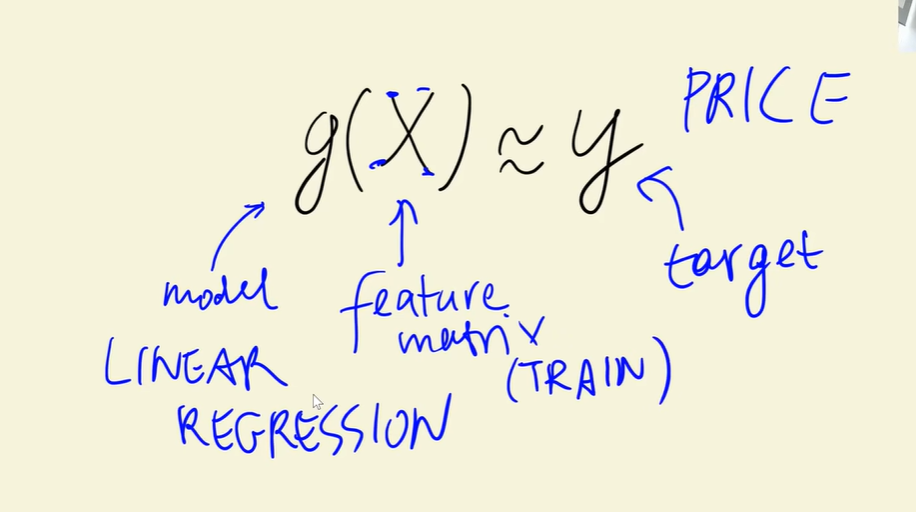

### Single observation

The goal is to create a model that will take in a list of features (characteristics of a car) and produce a good prediction (approximation) of the target (price)

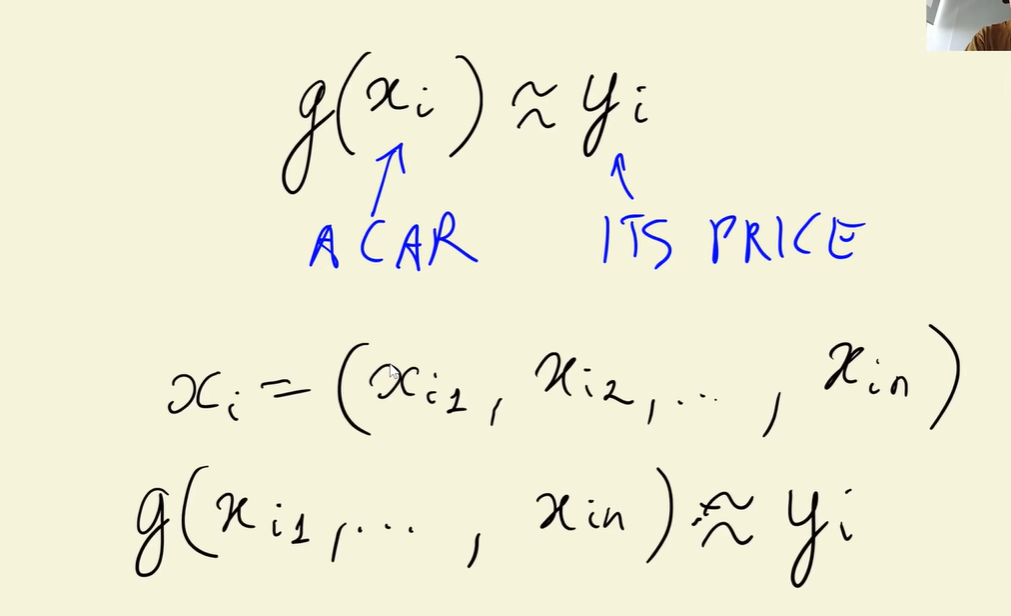

In [43]:
df_train.iloc[10]

make                                 rolls-royce
model                     phantom_drophead_coupe
year                                        2015
engine_fuel_type     premium_unleaded_(required)
engine_hp                                  453.0
engine_cylinders                            12.0
transmission_type                      automatic
driven_wheels                   rear_wheel_drive
number_of_doors                              2.0
market_category        exotic,luxury,performance
vehicle_size                               large
vehicle_style                        convertible
highway_mpg                                   19
city_mpg                                      11
popularity                                    86
Name: 10, dtype: object

### Formula

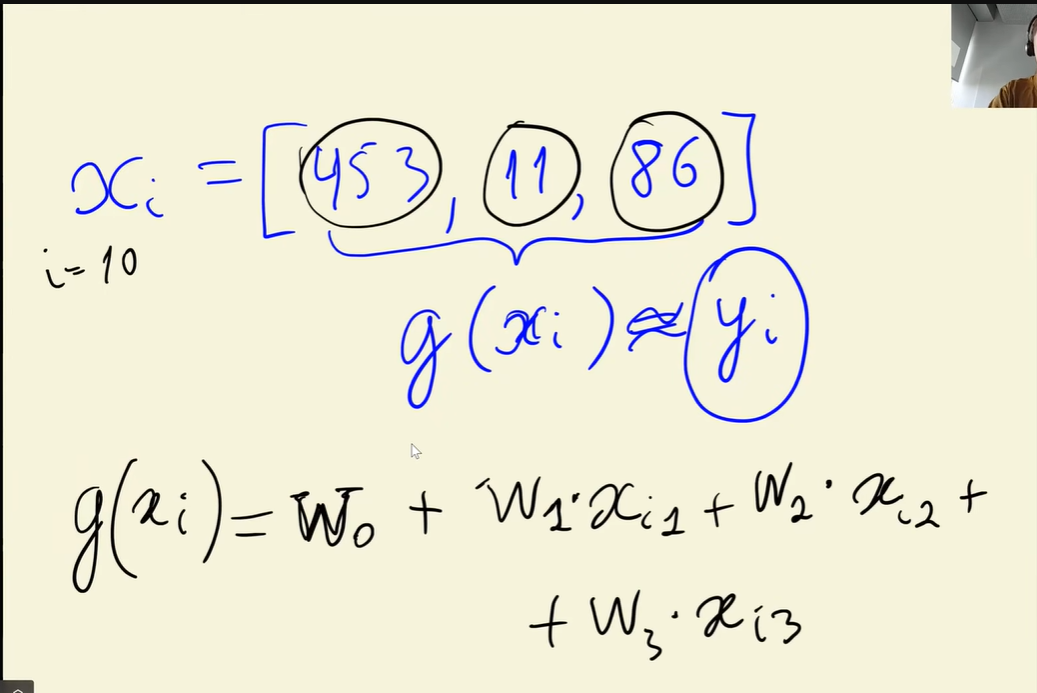

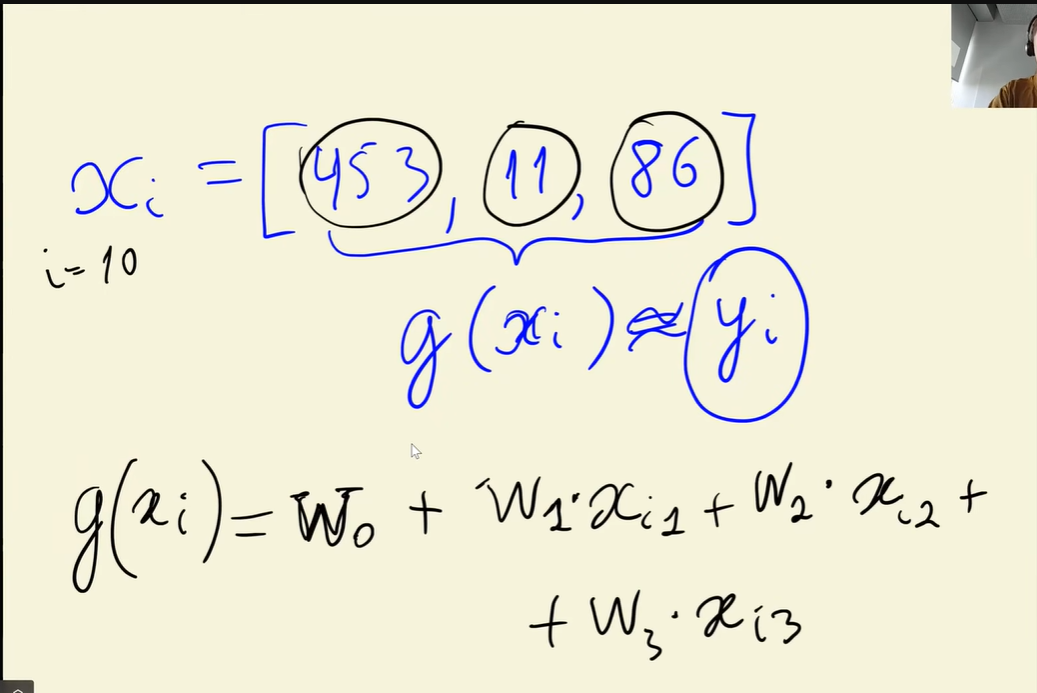

### Implementation

In [44]:
xi = df_train.loc[10, ['engine_hp', 'city_mpg', 'popularity']]
xi

engine_hp     453.0
city_mpg       11.0
popularity     86.0
Name: 10, dtype: float64

In [45]:
# In practice, the bias and weights values would be learned from training data
bias = 7.17
weights = [0.01, 0.04, 0.002]

def linear_regression(xi):
    n = len(xi)

    # Start with the bias
    pred = bias

    # For each feature, multiply the weight by the value of the feature
    for j in range(n):
        pred += weights[j] * xi.iloc[j]

    return pred


prediction = linear_regression(xi)
prediction

np.float64(12.312)

### Get the original scale using exponents

- Since we used a logarithmic transformation (`log1p`) on the target (`price`) column, the model outputs a price in log units.
- To get the value in the original units, we need to apply an exponent transformation (`expm1`) to reverse the log transformation.

In [46]:
original_price = np.expm1(prediction).round(2)
original_price

np.float64(222347.22)

## Linear Regression (Vector Form)

### Linear regression - dot product

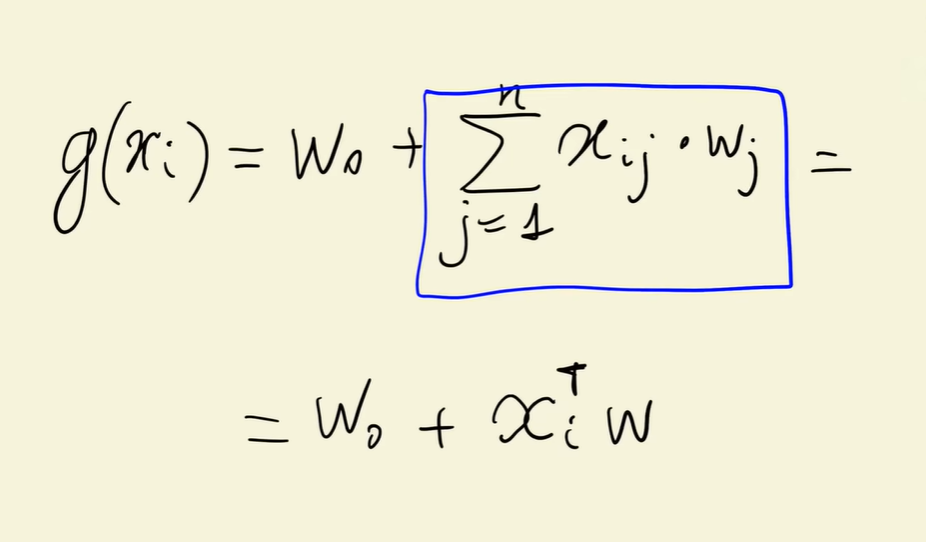

In [47]:
def dot(xi, w):
    n = len(xi)

    result = 0.0

    for j in range(n):
        result += w[j] * xi[j]

    return result

def linear_regression(xi):
    return bias + dot(xi, weights)

### Even shorter notation

Here, we fold the bias term into the dot product summation

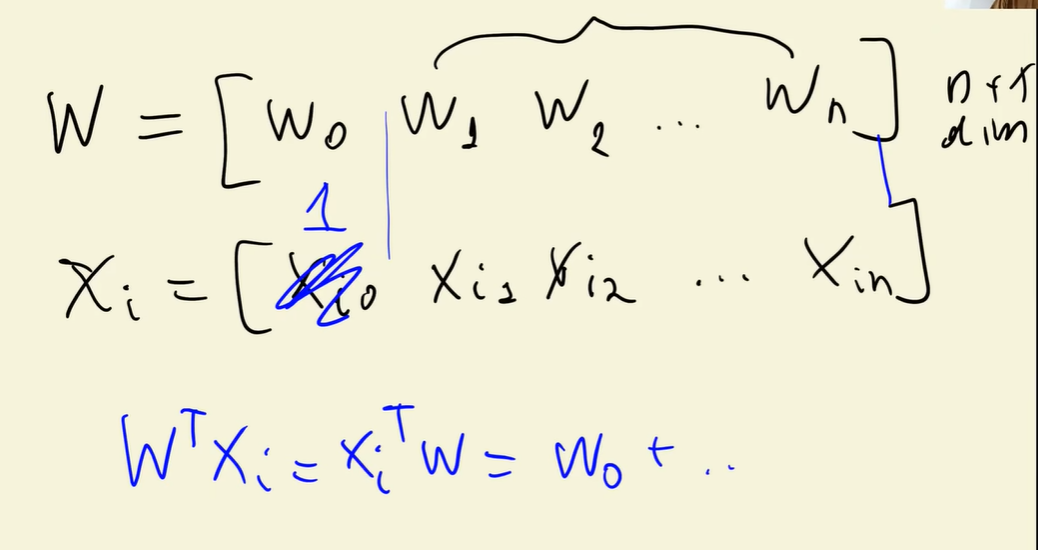

In [48]:
# Combine the bias and weights into a single list
w_new = [bias] + weights

w_new

[7.17, 0.01, 0.04, 0.002]

In [49]:
def linear_regression(xi):
    xi = [1] + xi.tolist()
    return dot(xi, w_new)


linear_regression(xi)

12.312

### Connecting vector-matrix multiplication to making predictions

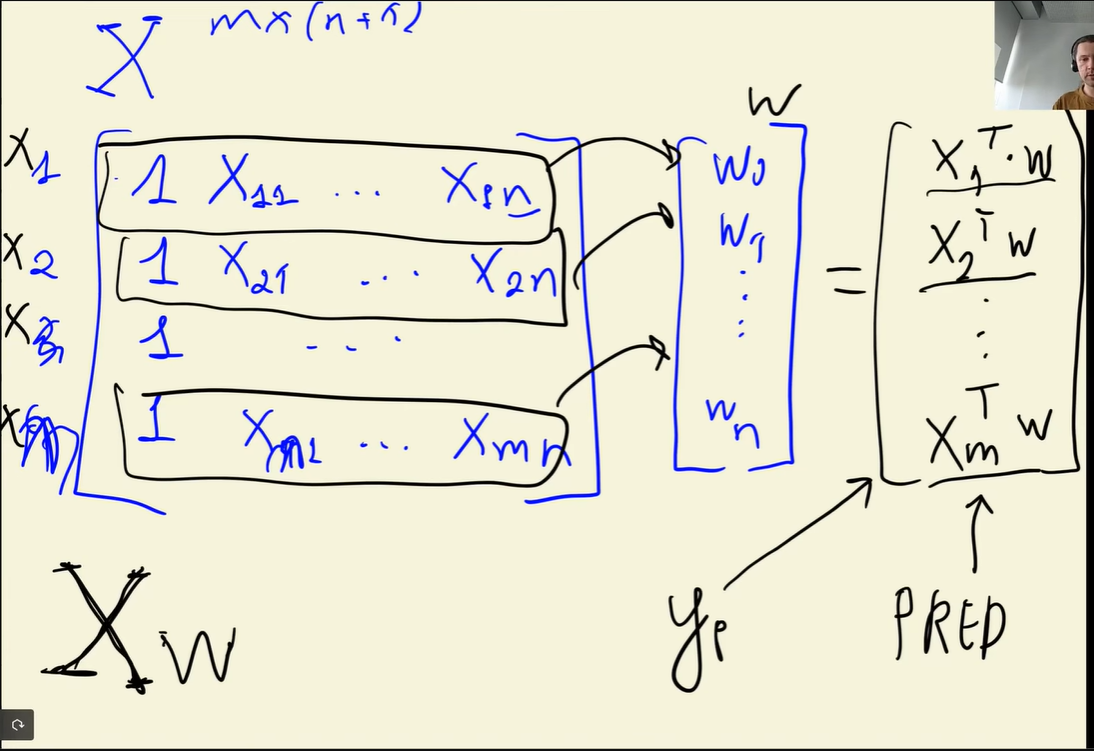

In [50]:
# Setup feature matrix
x1  = [1, 148, 24, 1385]
x2  = [1, 132, 25, 2031]
x10 = [1, 453, 11, 86]

X = np.array([x1, x2, x10])
X

array([[   1,  148,   24, 1385],
       [   1,  132,   25, 2031],
       [   1,  453,   11,   86]])

In [51]:
# Weights and bias combined into a single list
w_new

[7.17, 0.01, 0.04, 0.002]

In [52]:
# Make predictions
def linear_regression(X):
    return np.dot(X, w_new)

linear_regression(X)

array([12.38 , 13.552, 12.312])

## Train Linear Regression

### Normal Equation

Recap of linear regression formula

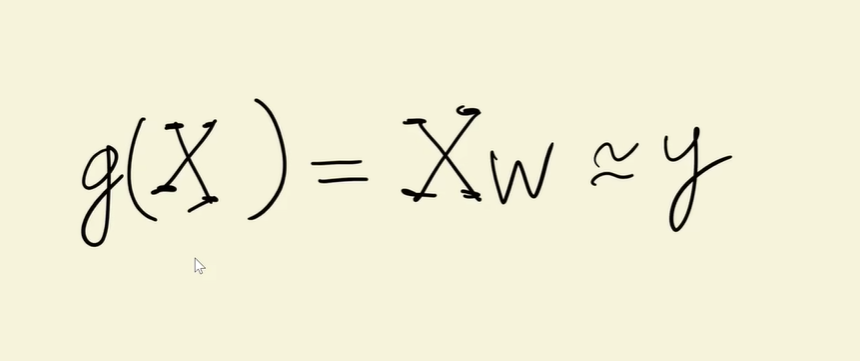

If the inverse of X existed, the formula to find w would simply look like this:

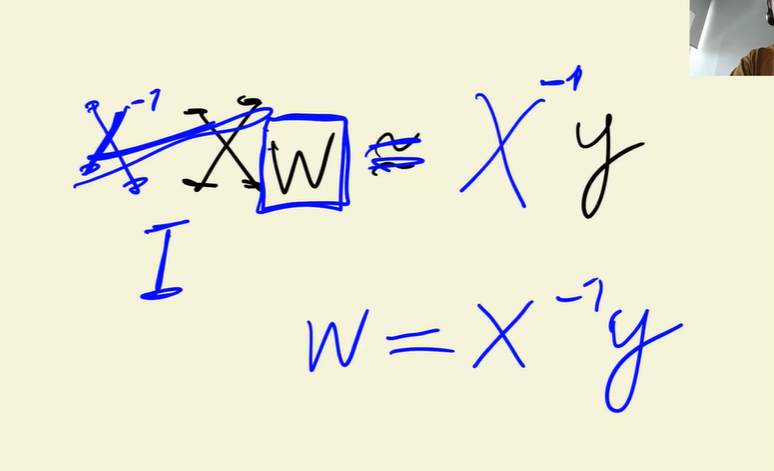

However, since most (if not all) feature matrixes are not square (rectangular because there are more rows than columns), the inverse of X DOES NOT EXIST.

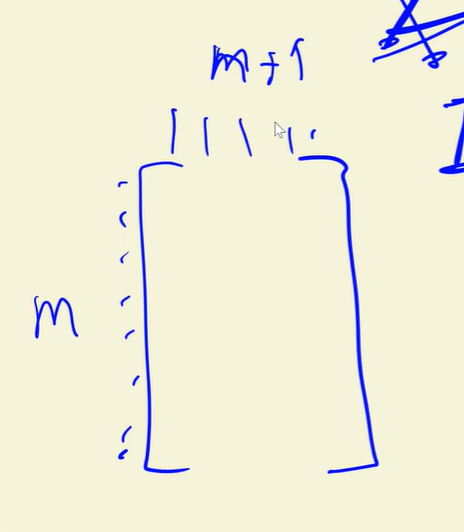

**Alternative solution:** we can find an approximate (not exact) solution, by finding the ***inverse of the gram matrix*** (this time, the inverse does exist - but not all the time)

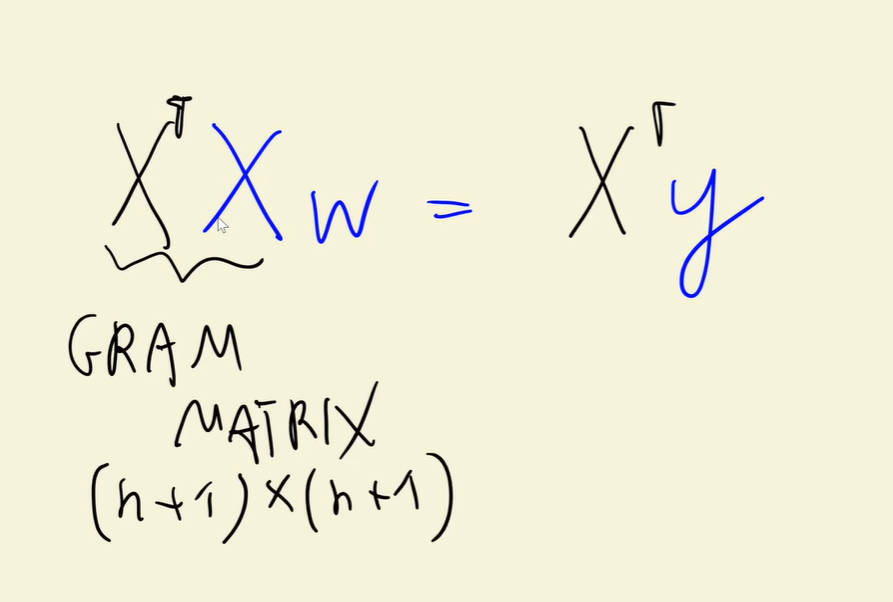

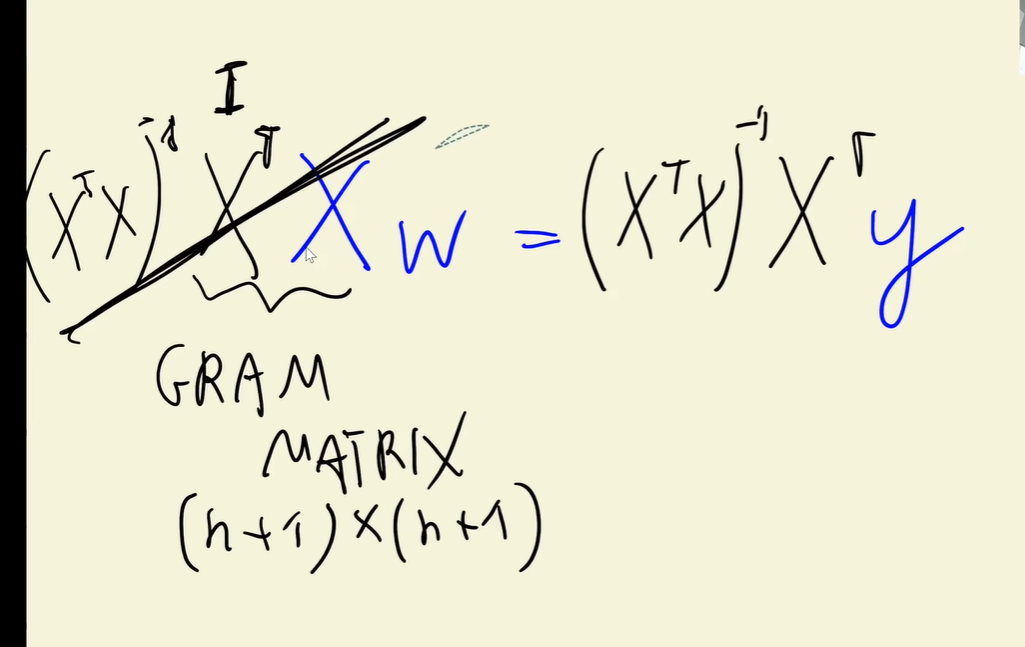

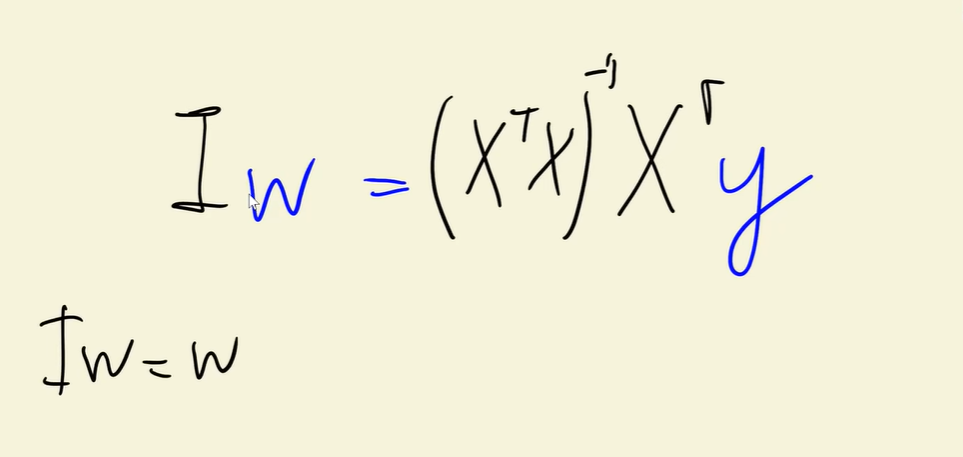

This gives us the formula for the **Normal Equation**


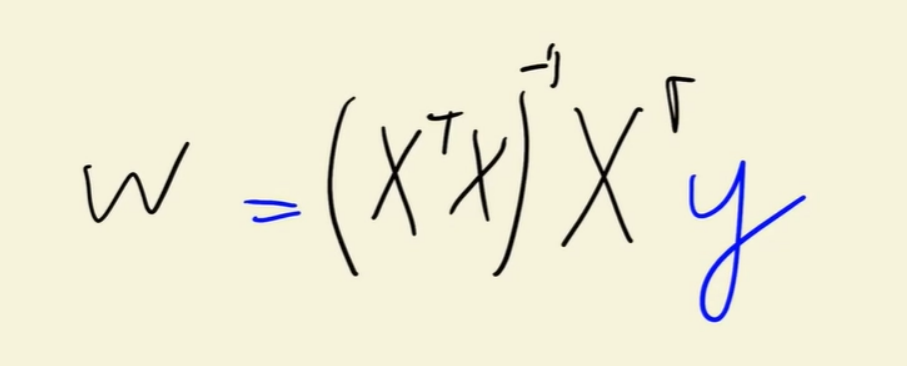

**Remember:** The Normal Equation does not give us the exact solution to get the weights, but it does give us a close enough approximation

### Implementation

In [53]:
# First, create a feature matrix (X)
X = np.array([
    [148, 24, 1385],
    [132, 25, 2031],
    [453, 11, 86],
    [158, 24, 185],
    [172, 25, 201],
    [413, 11, 86],
    [38,  54, 185],
    [142, 25, 431],
    [453, 31, 86],
])

X


array([[ 148,   24, 1385],
       [ 132,   25, 2031],
       [ 453,   11,   86],
       [ 158,   24,  185],
       [ 172,   25,  201],
       [ 413,   11,   86],
       [  38,   54,  185],
       [ 142,   25,  431],
       [ 453,   31,   86]])

In [54]:
# Add the bias term
ones = np.ones(X.shape[0])
ones

array([1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [55]:
# column_stack combines the bias term with the feature matrix
X = np.column_stack([ones, X])
X

array([[   1.,  148.,   24., 1385.],
       [   1.,  132.,   25., 2031.],
       [   1.,  453.,   11.,   86.],
       [   1.,  158.,   24.,  185.],
       [   1.,  172.,   25.,  201.],
       [   1.,  413.,   11.,   86.],
       [   1.,   38.,   54.,  185.],
       [   1.,  142.,   25.,  431.],
       [   1.,  453.,   31.,   86.]])

In [56]:
# Create the Gram matrix
XTX = np.dot(X.T, X)
XTX

array([[      9.,    2109.,     230.,    4676.],
       [   2109.,  696471.,   44115.,  718540.],
       [    230.,   44115.,    7146.,  118803.],
       [   4676.,  718540.,  118803., 6359986.]])

In [57]:
# Get inverse of Gram matrix
XTX_inv = np.linalg.inv(XTX)
XTX_inv

array([[ 3.30686958, -0.00539612, -0.06213256, -0.00066102],
       [-0.00539612,  0.00001116,  0.0000867 ,  0.00000109],
       [-0.06213256,  0.0000867 ,  0.00146189,  0.00000858],
       [-0.00066102,  0.00000109,  0.00000858,  0.00000036]])

In [58]:
# Sanity check: multiply the Gram matrix by its inverse
# Should result in the identity matrix
np.dot(XTX, XTX_inv).round(1)

array([[ 1., -0.,  0.,  0.],
       [-0.,  1.,  0., -0.],
       [-0.,  0.,  1.,  0.],
       [-0., -0.,  0.,  1.]])

In [59]:
# Target values
y = [10000, 20000, 15000, 20050, 10000, 20000, 15000, 25000, 12000]
y

[10000, 20000, 15000, 20050, 10000, 20000, 15000, 25000, 12000]

In [60]:
# Normal equation
w_full = XTX_inv.dot(X.T).dot(y)
w_full

array([25844.75405577,   -16.08906468,  -199.47254894,    -1.22802883])

In [61]:
# Extract the bias
bias = w_full[0]
bias

np.float64(25844.754055766833)

In [62]:
# Extract the weights
weights = w_full[1:]
weights

array([ -16.08906468, -199.47254894,   -1.22802883])

### Training function

In [63]:
# Combine everything we did earlier into a reusable function
def train_linear_regression(X, y):

    # Add the bias term
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    # Create the Gram matrix
    XTX = np.dot(X.T, X)

    # Get inverse of Gram matrix
    XTX_inv = np.linalg.inv(XTX)

    # Normal equation
    w_full = XTX_inv.dot(X.T).dot(y)

    # Extract the bias and weights
    bias = w_full[0]
    weights = w_full[1:]

    return bias, weights

In [64]:
X = np.array([
    [148, 24, 1385],
    [132, 25, 2031],
    [453, 11, 86],
    [158, 24, 185],
    [172, 25, 201],
    [413, 11, 86],
    [38,  54, 185],
    [142, 25, 431],
    [453, 31, 86],
])

y = [10000, 20000, 15000, 20050, 10000, 20000, 15000, 25000, 12000]

bias, weights = train_linear_regression(X, y)

print(f'Bias: {bias}')
print(f'Weights: {weights}')

Bias: 25844.754055766833
Weights: [ -16.08906468 -199.47254894   -1.22802883]


## Baseline Model

### EDA

In [65]:
df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657


In [66]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 7150 entries, 0 to 7149
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   make               7150 non-null   str    
 1   model              7150 non-null   str    
 2   year               7150 non-null   int64  
 3   engine_fuel_type   7149 non-null   str    
 4   engine_hp          7110 non-null   float64
 5   engine_cylinders   7136 non-null   float64
 6   transmission_type  7150 non-null   str    
 7   driven_wheels      7150 non-null   str    
 8   number_of_doors    7144 non-null   float64
 9   market_category    4899 non-null   str    
 10  vehicle_size       7150 non-null   str    
 11  vehicle_style      7150 non-null   str    
 12  highway_mpg        7150 non-null   int64  
 13  city_mpg           7150 non-null   int64  
 14  popularity         7150 non-null   int64  
dtypes: float64(3), int64(4), str(8)
memory usage: 838.0 KB


### Extract needed features and targets

In [67]:
features = [
    'engine_hp', 
    'engine_cylinders', 
    'highway_mpg',
    'city_mpg', 
    'popularity'
]

X_train = df_train[features].values

X_train[:10]

array([[ 148.,    4.,   33.,   24., 1385.],
       [ 132.,    4.,   32.,   25., 2031.],
       [ 148.,    4.,   37.,   28.,  640.],
       [  90.,    4.,   18.,   16.,  873.],
       [ 385.,    8.,   21.,   15., 5657.],
       [ 170.,    5.,   29.,   22.,  873.],
       [ 500.,    8.,   24.,   14.,  520.],
       [ 315.,    6.,   32.,   21., 3916.],
       [ 543.,   12.,   16.,   10.,   67.],
       [ 202.,    6.,   18.,   13., 5657.]])

In [68]:
y_train[:5]

array([ 9.57574708,  9.887663  ,  9.89323518,  7.60140233, 10.93775686])

### Handle missing values

This is the reason why we can't have missing values in our dataset

In [69]:
train_linear_regression(X_train, y_train)

(np.float64(nan), array([nan, nan, nan, nan, nan]))

Spot the missing values

In [70]:
df_train[features].isnull().sum()

engine_hp           40
engine_cylinders    14
highway_mpg          0
city_mpg             0
popularity           0
dtype: int64

In [71]:
# Check for missing values again
df_train[features].fillna(0).isnull().sum()

engine_hp           0
engine_cylinders    0
highway_mpg         0
city_mpg            0
popularity          0
dtype: int64

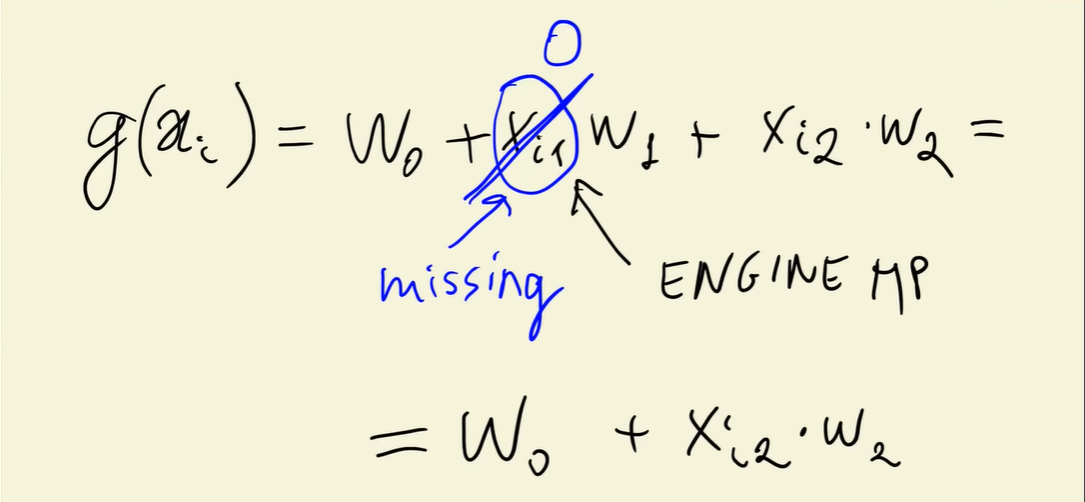

Filling missing values with just 0 is not always the right choice. 

This is where your domain expertise should shine, since you should know what is the best method to handle nulls based on your expertise in the field and its data.

In [72]:
X_train_clean = df_train[features].fillna(0).values
X_train_clean[:10]

array([[ 148.,    4.,   33.,   24., 1385.],
       [ 132.,    4.,   32.,   25., 2031.],
       [ 148.,    4.,   37.,   28.,  640.],
       [  90.,    4.,   18.,   16.,  873.],
       [ 385.,    8.,   21.,   15., 5657.],
       [ 170.,    5.,   29.,   22.,  873.],
       [ 500.,    8.,   24.,   14.,  520.],
       [ 315.,    6.,   32.,   21., 3916.],
       [ 543.,   12.,   16.,   10.,   67.],
       [ 202.,    6.,   18.,   13., 5657.]])

In [73]:
bias, weights = train_linear_regression(X_train_clean, y_train)

print(X_train_clean.shape, weights.shape)


(7150, 5) (5,)


In [74]:
y_pred = bias + X_train_clean.dot(weights)
y_pred

array([ 9.54792783,  9.38733977,  9.67197758, ..., 10.30423015,
       11.9778914 ,  9.99863111], shape=(7150,))

### Visualize results

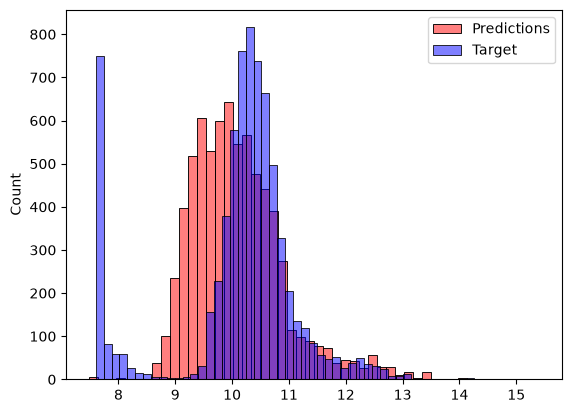

In [75]:
sns.histplot(y_pred, color='red', alpha=0.5, bins=50, label='Predictions')
sns.histplot(y_train, color='blue', alpha=0.5, bins=50, label='Target')
plt.legend()
plt.show()

## Root Mean Squared Error (RMSE)

### Whole formula

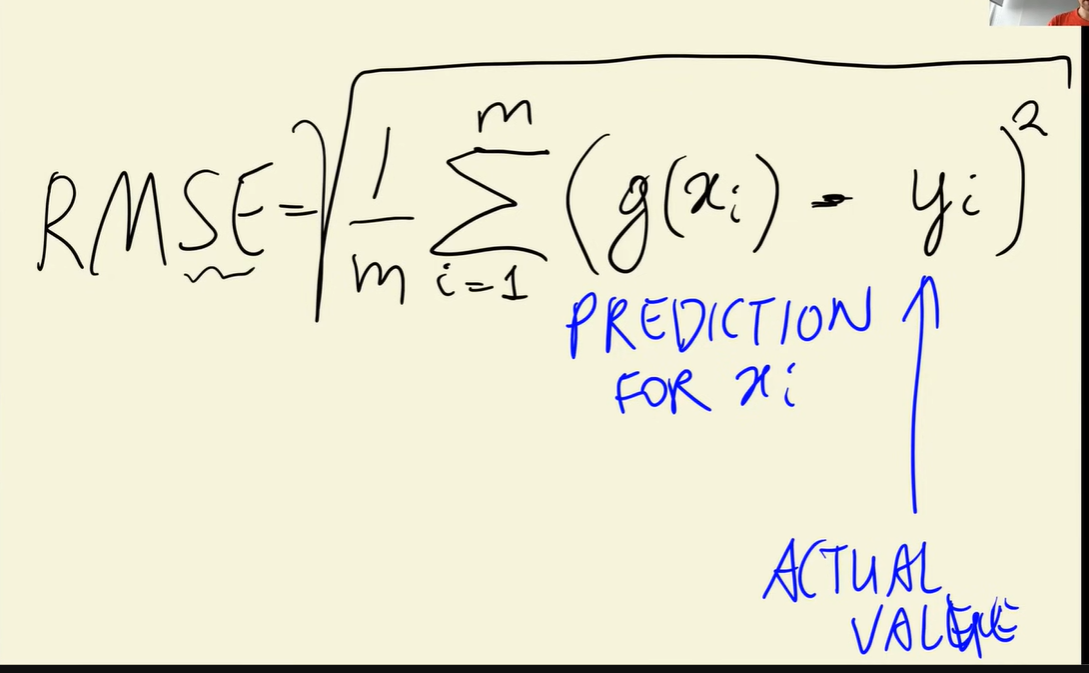

### Breakdown the formula

1. Compute difference between prediction and actual values (error)

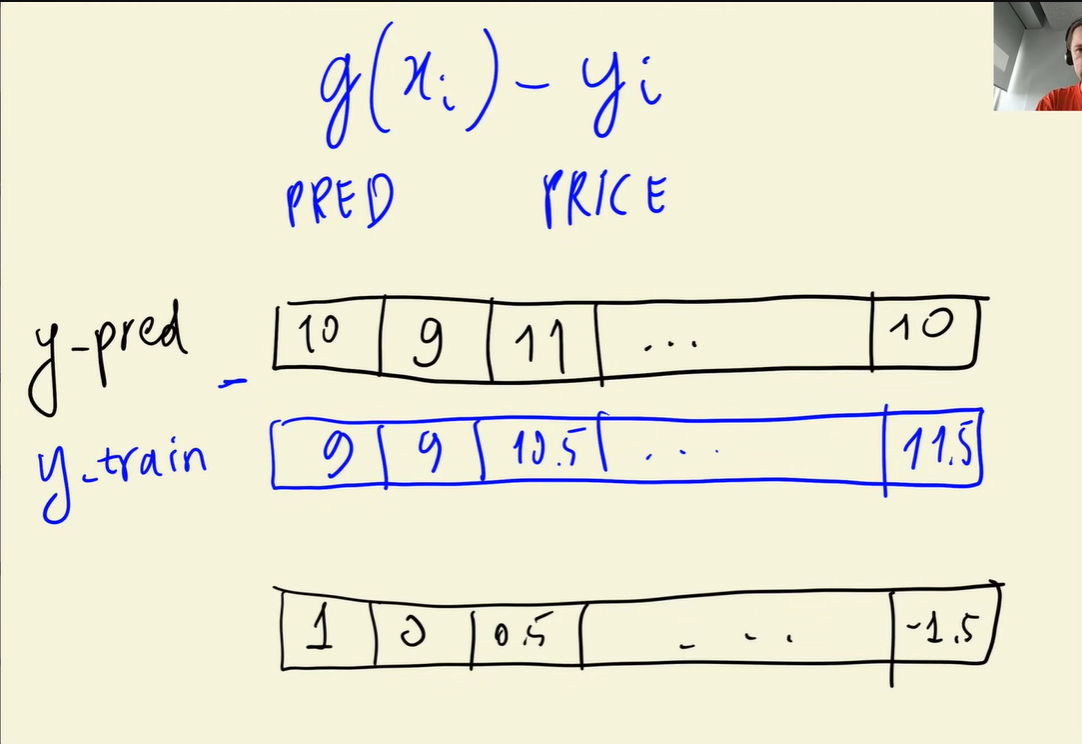

2. Square each of the differences/errors

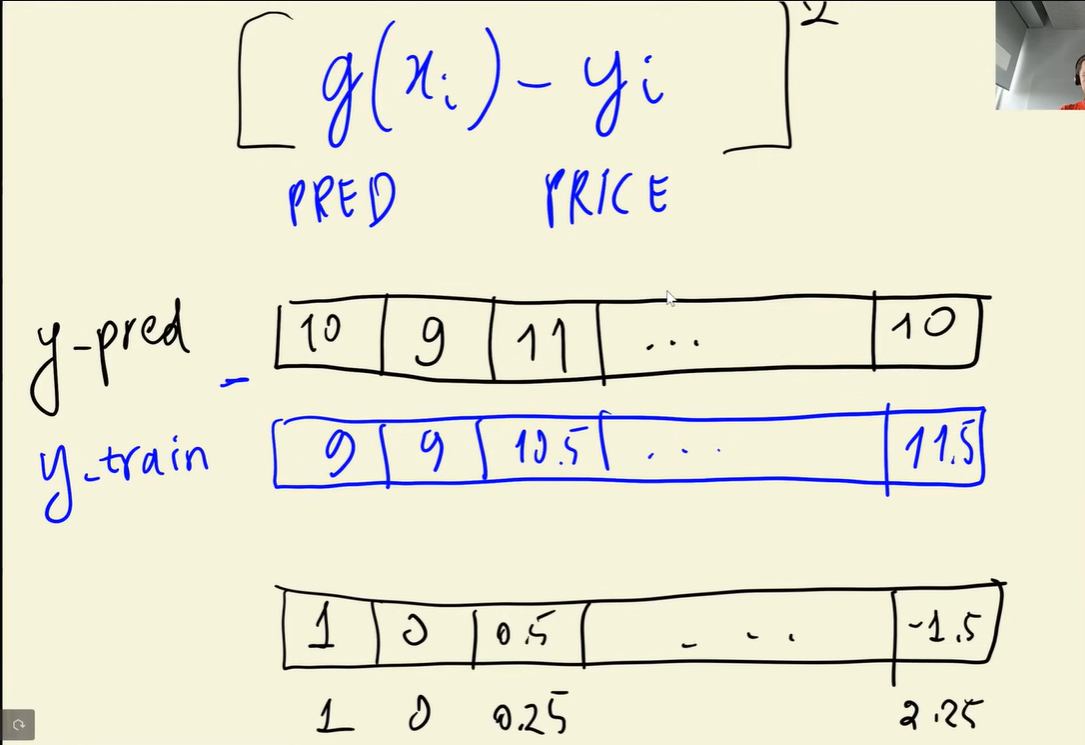

3. Compute the average of the squared errors

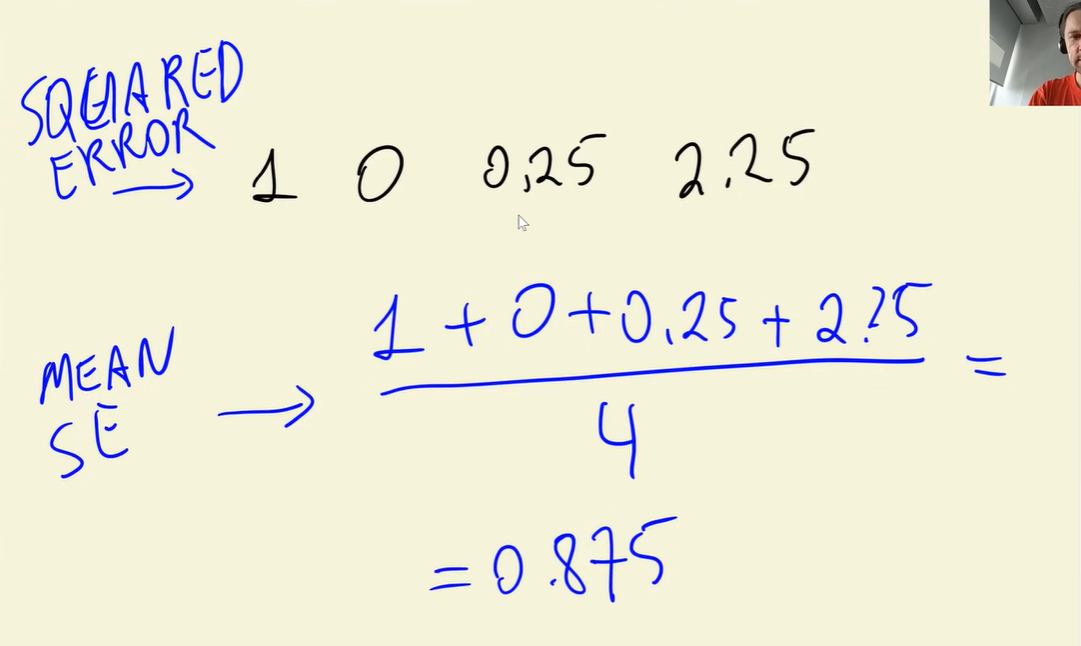

4. Get the square root of the mean squared error (so that we get the original units  - prev step squared the units)

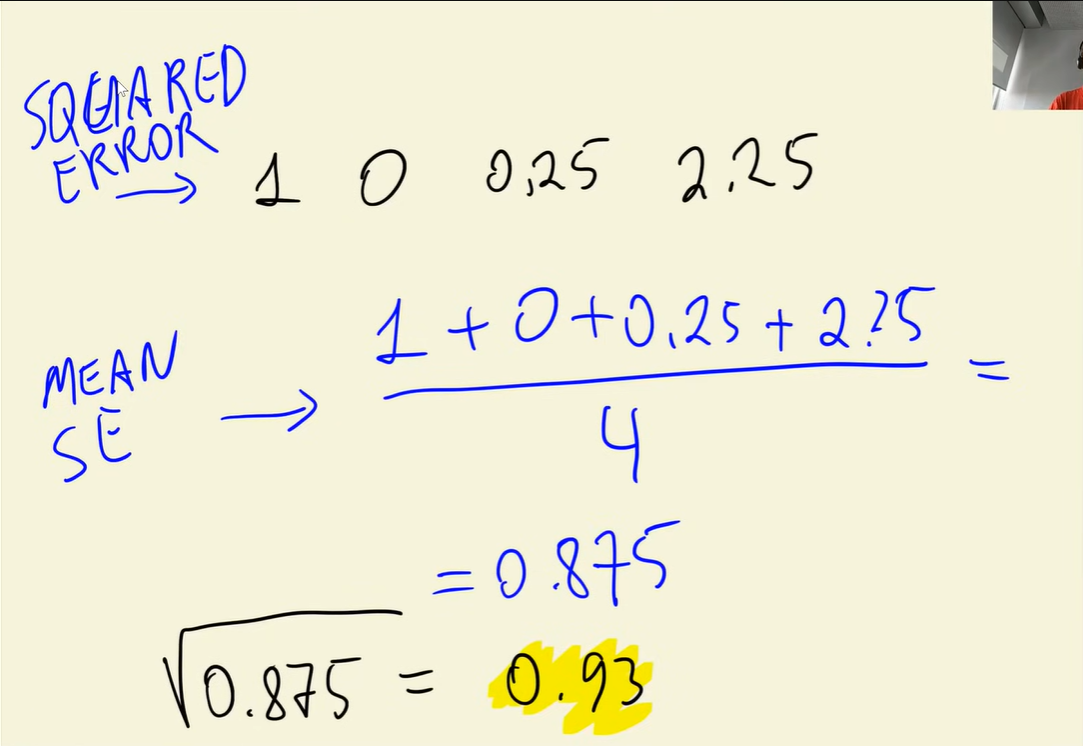

### Code implementation

In [76]:
def rmse(y_actual, y_pred):

    errors = y_actual - y_pred

    squared_erors = errors ** 2

    mse = np.mean(squared_erors)

    rmse = np.sqrt(mse)

    return rmse


rmse(y_train, y_pred)


np.float64(0.7554192603920132)

## Validating the Model

Proper way of validating our model:
- Train the model using the training set
- Compute RMSE on the validation set

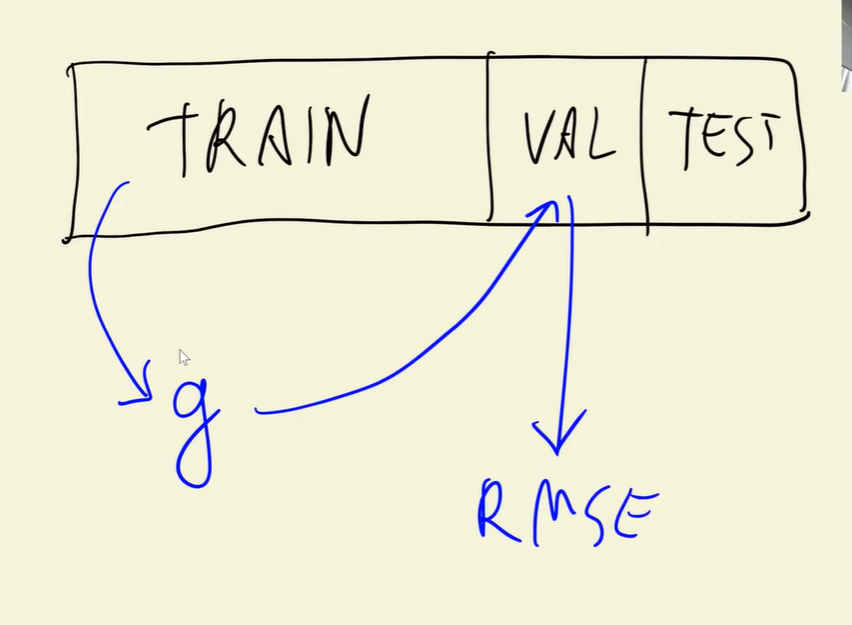

### Prepare training set

In [77]:
def prepare_X(df, features):
    X = df[features]
    X = X.fillna(0)
    X = X.values
    return X

In [78]:
df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657


In [79]:
features = [
    'engine_hp', 
    'engine_cylinders', 
    'highway_mpg',
    'city_mpg', 
    'popularity'
]

X_train = prepare_X(df_train, features)
X_train


array([[ 148.,    4.,   33.,   24., 1385.],
       [ 132.,    4.,   32.,   25., 2031.],
       [ 148.,    4.,   37.,   28.,  640.],
       ...,
       [ 285.,    6.,   22.,   17.,  549.],
       [ 563.,   12.,   21.,   13.,   86.],
       [ 200.,    4.,   31.,   22.,  873.]], shape=(7150, 5))

### Train the model

In [80]:
bias, weights = train_linear_regression(X_train, y_train)

print(f'Bias: ', bias)
print(f'Weights: ', weights)

Bias:  7.927257388070037
Weights:  [ 0.0097059  -0.15910349  0.01437921  0.01494411 -0.00000907]


### Prepare the validation set

In [81]:
X_val = prepare_X(df_val, features)

X_val

array([[ 200.,    4.,   25.,   19., 1385.],
       [ 241.,    4.,   29.,   22.,  617.],
       [ 160.,    4.,   36.,   26., 5657.],
       ...,
       [ 332.,    8.,   23.,   20., 1624.],
       [ 148.,    4.,   34.,   24.,  436.],
       [ 290.,    6.,   25.,   18., 1720.]], shape=(2382, 5))

### Generate predictions

In [82]:
# We use the weights and bias learned from training set
y_pred = bias + X_val.dot(weights)
y_pred

array([ 9.86288014, 10.37013608,  9.69868129, ..., 10.4916625 ,
        9.57091361, 10.40022147], shape=(2382,))

### Evaluate model

In [83]:
rmse(y_val, y_pred)

np.float64(0.7616530991301627)

### Visualize predictions

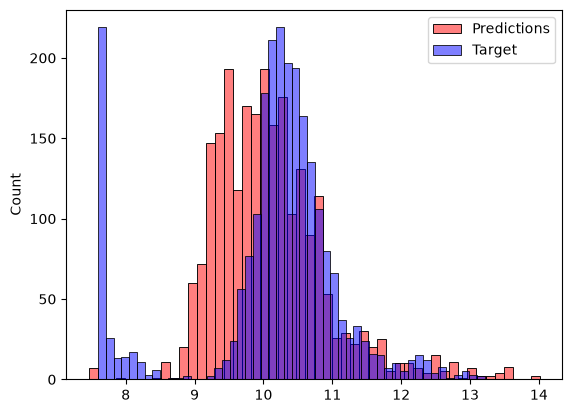

In [84]:
sns.histplot(y_pred, color='red', alpha=0.5, bins=50, label='Predictions')
sns.histplot(y_val, color='blue', alpha=0.5, bins=50, label='Target')
plt.legend()
plt.show()

## Feature Engineering

### Add a new feature

Aside from the original features already included in our dataset, we can create new features that can help with predicting the price of a car.

One such feature is the age of a car. Newer cards tend to be priced higher, while older cars tend to have lower prices. Because of this, the age of the car can be used to help predict its price.

In [85]:
def prepare_X(df, features):

    # Create copy so we don't affect the original df
    df = df.copy()

    # Add new feature
    df['age'] = 2017 - df['year']

    # Combine new feature with existing features
    all_features = features + ['age']

    X = df[all_features]
    X = X.fillna(0)
    X = X.values
    
    return X

In [86]:
# Prep the training data (with the new age feature)
X_train = prepare_X(df_train, features)
X_train

# Train a new model
bias, weights = train_linear_regression(X_train, y_train)

# Prep the validation data
X_val = prepare_X(df_val, features)

# Generate predictions
y_pred = bias + X_val.dot(weights)

# Evaluate
rmse(y_val, y_pred)


np.float64(0.5172055461058327)

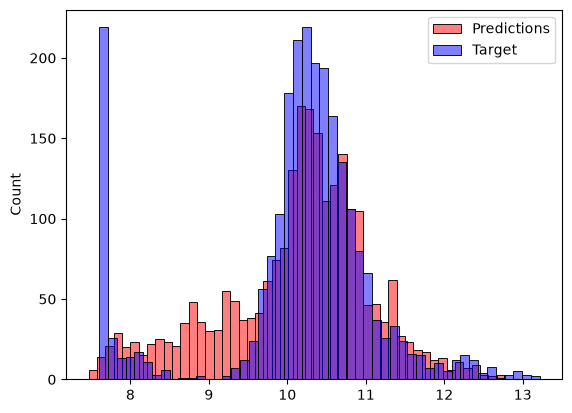

In [87]:
sns.histplot(y_pred, color='red', alpha=0.5, bins=50, label='Predictions')
sns.histplot(y_val, color='blue', alpha=0.5, bins=50, label='Target')
plt.legend()
plt.show()

## Categorical Variables

### Overview

Categorical variables are features whose values are based on a limited set of categories.

They are typically stored as `string` or `object` type in pandas

In [88]:
df.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

However, not all categorical variables are string or object. Some may look like numerical columns but are actually categorical because the values are from a distinct, limited set of possible choices. 

Example of such is `number_of_doors`

In [89]:
df['number_of_doors']

0        2.0
1        2.0
2        2.0
3        2.0
4        2.0
        ... 
11909    4.0
11910    4.0
11911    4.0
11912    4.0
11913    4.0
Name: number_of_doors, Length: 11914, dtype: float64

### One-hot encoding

ML models can't take categorical variables in their raw state. 

For us to use categorical variables as features, we must first transform them into binary columns using a process called ***one-hot encoding***.

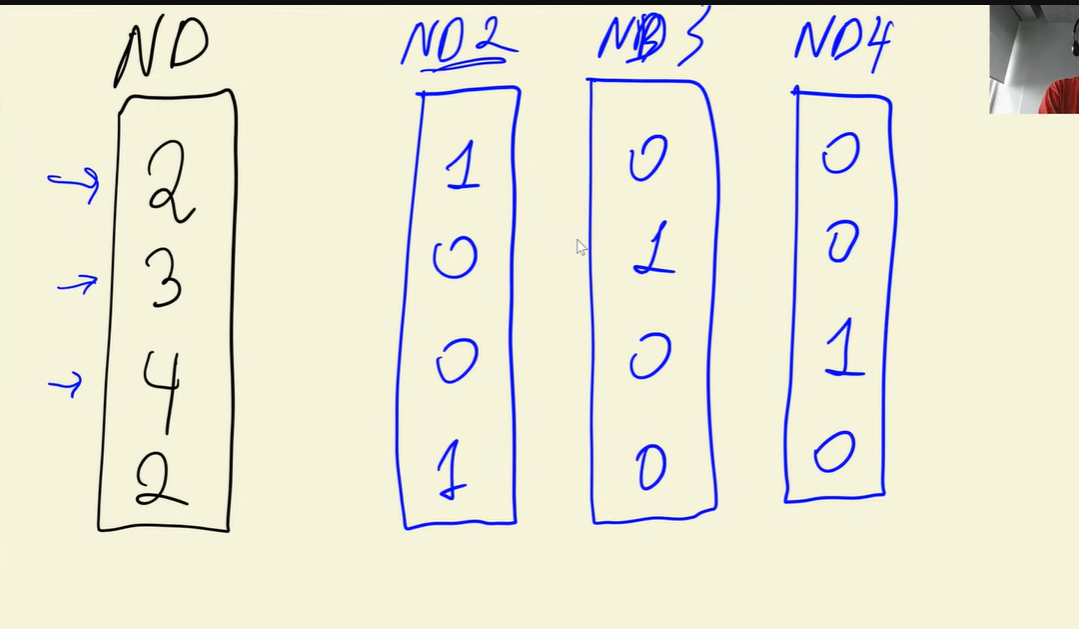

In [90]:
# Do this as well to the other unique values of the column
df_train['number_of_doors'] == 2

0        True
1       False
2       False
3       False
4       False
        ...  
7145     True
7146     True
7147    False
7148    False
7149    False
Name: number_of_doors, Length: 7150, dtype: bool

In [91]:
# Do this as well to the other unique values of the column
(df_train['number_of_doors'] == 2).astype('int')

0       1
1       0
2       0
3       0
4       0
       ..
7145    1
7146    1
7147    0
7148    0
7149    0
Name: number_of_doors, Length: 7150, dtype: int64

In [92]:
for v in [2, 3, 4]:
    df_train[f'num_doors_{v}'] = (df_train['number_of_doors'] == v).astype('int')

df_train.head(10)

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,num_doors_2,num_doors_3,num_doors_4
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,1,0,0
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,0,0,1
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,0,0,1
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,0,1,0
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,0,0,1
5,volkswagen,rabbit,2008,regular_unleaded,170.0,5.0,manual,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,29,22,873,0,0,1
6,bentley,continental_gtc,2013,premium_unleaded_(required),500.0,8.0,automatic,all_wheel_drive,2.0,"exotic,luxury,high-performance",midsize,convertible,24,14,520,1,0,0
7,bmw,6_series,2015,premium_unleaded_(required),315.0,6.0,automatic,rear_wheel_drive,2.0,"luxury,performance",midsize,coupe,32,21,3916,1,0,0
8,maybach,57,2012,premium_unleaded_(required),543.0,12.0,automatic,rear_wheel_drive,4.0,"exotic,luxury",large,sedan,16,10,67,0,0,1
9,ford,f-150_heritage,2004,regular_unleaded,202.0,6.0,manual,four_wheel_drive,2.0,NaN,large,regular_cab_pickup,18,13,5657,1,0,0


In [93]:
for v in [2, 3, 4]:
    del df_train[f'num_doors_{v}']

df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657


### Add one-hot encoding to the pipeline

In [94]:
def prepare_X(df, features):

    # Create copy so we don't affect the original df
    df = df.copy()
    features = list(features)

    # Add new feature
    df['age'] = 2017 - df['year']
    features.append('age')

    # One-hot encoding
    for v in [2, 3, 4]:
        df[f'num_doors_{v}'] = (df['number_of_doors'] == v).astype('int')
        features.append(f'num_doors_{v}')

    X = df[features]

    # Handle missing values
    X = X.fillna(0)

    # Convert to numpy array
    X = X.values
    
    return X

Train and validate model with the new categorical variable

In [95]:
# Prep the training data (with the new age feature)
X_train = prepare_X(df_train, features)
X_train

# Train a new model
bias, weights = train_linear_regression(X_train, y_train)

# Prep the validation data
X_val = prepare_X(df_val, features)

# Generate predictions
y_pred = bias + X_val.dot(weights)

# Evaluate
rmse(y_val, y_pred)


np.float64(0.5157995641501902)

### Add additional categorial features

Make

In [96]:
df['make'].value_counts()

make
chevrolet        1123
ford              881
volkswagen        809
toyota            746
dodge             626
nissan            558
gmc               515
honda             449
mazda             423
cadillac          397
mercedes-benz     353
suzuki            351
bmw               334
infiniti          330
audi              328
hyundai           303
volvo             281
subaru            256
acura             252
kia               231
mitsubishi        213
lexus             202
buick             196
chrysler          187
pontiac           186
lincoln           164
oldsmobile        150
land_rover        143
porsche           136
saab              111
aston_martin       93
plymouth           82
bentley            74
ferrari            69
fiat               62
scion              60
maserati           58
lamborghini        52
rolls-royce        31
lotus              29
tesla              18
hummer             17
maybach            16
alfa_romeo          5
mclaren             5
spyke

In [97]:
makes = list(df['make'].value_counts().head().index)
makes

['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge']

In [98]:
def prepare_X(df, features):

    # Create copy so we don't affect the original df
    df = df.copy()
    features = list(features)

    # Add new feature
    df['age'] = 2017 - df['year']
    features.append('age')

    # One-hot encoding
    for v in [2, 3, 4]:
        df[f'num_doors_{v}'] = (df['number_of_doors'] == v).astype('int')
        features.append(f'num_doors_{v}')

    # Makes
    for v in makes:
        df[f'make_{v}'] = (df['make'] == v).astype('int')
        features.append(f'make_{v}')

    X = df[features]

    # Handle missing values
    X = X.fillna(0)

    # Convert to numpy array
    X = X.values
    
    return X


# Prep the training data (with the new age feature)
X_train = prepare_X(df_train, features)
X_train

# Train a new model
bias, weights = train_linear_regression(X_train, y_train)

# Prep the validation data
X_val = prepare_X(df_val, features)

# Generate predictions
y_pred = bias + X_val.dot(weights)

# Evaluate
rmse(y_val, y_pred)


np.float64(0.5076038849556633)

### Automate one-hot encoding for many categorical features

In [99]:
categories = [
    'make', 'engine_fuel_type', 'transmission_type', 'driven_wheels',
    'market_category', 'vehicle_size', 'vehicle_style'
]

top5_vals_per_category = {}

for cat in categories:
    top5_vals_per_category[cat] = list(df[cat].value_counts().head().index)

pprint(top5_vals_per_category, sort_dicts=False)

{'make': ['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge'],
 'engine_fuel_type': ['regular_unleaded',
                      'premium_unleaded_(required)',
                      'premium_unleaded_(recommended)',
                      'flex-fuel_(unleaded/e85)',
                      'diesel'],
 'transmission_type': ['automatic',
                       'manual',
                       'automated_manual',
                       'direct_drive',
                       'unknown'],
 'driven_wheels': ['front_wheel_drive',
                   'rear_wheel_drive',
                   'all_wheel_drive',
                   'four_wheel_drive'],
 'market_category': ['crossover',
                     'flex_fuel',
                     'luxury',
                     'luxury,performance',
                     'hatchback'],
 'vehicle_size': ['compact', 'midsize', 'large'],
 'vehicle_style': ['sedan', '4dr_suv', 'coupe', 'convertible', '4dr_hatchback']}


In [100]:
def prepare_X(df, features):

    # Create copy so we don't affect the original df
    df = df.copy()
    features = list(features)

    # Add new feature
    df['age'] = 2017 - df['year']
    features.append('age')

    # One-hot encoding
    for v in [2, 3, 4]:
        df[f'num_doors_{v}'] = (df['number_of_doors'] == v).astype('int')
        features.append(f'num_doors_{v}')

    # Additional categories
    for cat, values in top5_vals_per_category.items():
        for val in values:
            df[f'{cat}_{val}'] = (df[cat] == val).astype('int')
            features.append(f'{cat}_{val}')
            
    # Handle missing values
    df[features] = df[features].fillna(0)

    # Convert to numpy array
    X = df[features].values
    
    return X


# Prep the training data (with the new age feature)
X_train = prepare_X(df_train, features)

# Train a new model
bias, weights = train_linear_regression(X_train, y_train)

# Prep the validation data
X_val = prepare_X(df_val, features)

# Generate predictions
y_pred = bias + X_val.dot(weights)

# Evaluate
rmse(y_val, y_pred)


np.float64(20.255338567164987)

Something went wrong: now the RMSE is significantly higher

In [101]:
bias

np.float64(150710170147060.28)

In [102]:
weights

array([ 4.16837377e-04, -7.68909196e+00, -1.01756223e+00, -1.42662208e-01,
        5.73832489e-05, -2.26163471e-01,  1.59860520e+02,  1.50007800e+02,
        1.51055869e+02,  3.44763397e-01, -3.44331447e+00,  3.38975893e+00,
        5.28207842e-01, -1.91665109e-01, -6.28886267e+01, -5.25440824e+01,
       -5.74347468e+01, -5.86441570e+01, -7.63714974e+01, -4.81366260e+13,
       -4.81366260e+13, -4.81366260e+13, -4.81366260e+13, -4.81366260e+13,
       -1.02573544e+14, -1.02573544e+14, -1.02573544e+14, -1.02573544e+14,
        4.62217438e+00,  3.40402028e+00, -2.42020018e+00, -1.45600402e+00,
       -3.63356661e+00, -1.80046141e+01, -1.98554087e+01, -1.52560943e+01,
       -4.85492239e-02,  5.44797374e-02,  1.78241160e-01,  3.41906701e-01,
       -1.64412078e-01])

If we take a look at the bias and weights, they are now extreme values

## Regularization

### Problem

Recall the normal equation

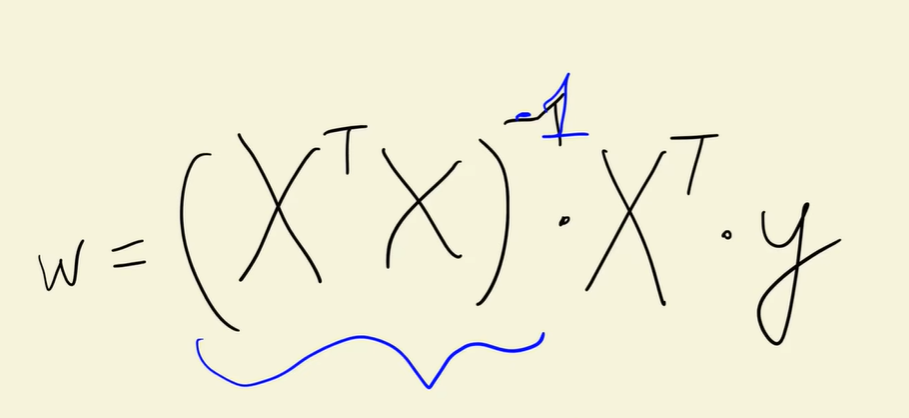

The problem we have is with this part: we need to take the inverse of the Gram matrix XᵀX, and sometimes this inverse doesn't exist.

It usually happens when the feature matrix X has duplicate columns. Let's quickly check it with a small matrix where the second and the third columns have the same values:

In [103]:
X = [
    [4, 4, 4],
    [3, 5, 5],
    [5, 1, 1],
    [5, 4, 4],
    [7, 5, 5],
    [4, 5, 5],
]

X = np.array(X)
X

array([[4, 4, 4],
       [3, 5, 5],
       [5, 1, 1],
       [5, 4, 4],
       [7, 5, 5],
       [4, 5, 5]])

Notice that the 2nd and 3rd columns are identical

In [104]:
gram_matrix = X.T.dot(X)
gram_matrix

array([[140, 111, 111],
       [111, 108, 108],
       [111, 108, 108]])

When we try to get the inverse, it does not exist, which is why get the error

In [105]:
# This will result in an error
# np.linalg.inv(gram_matrix)

Below, we added a very tiny decimal to one of the values. While it does not throw an error like the one above, the matrix is NEARLY singular, which is why it gave us extreme values

In [106]:
X = np.array([
    [4, 4, 4],
    [3, 5, 5],
    [5, 1, 1],
    [5, 4, 4],
    [7, 5, 5],
    [4, 5, 5.000001],
])

gram_matrix = X.T.dot(X)
gram_matrix


array([[140.      , 111.      , 111.000004],
       [111.      , 108.      , 108.000005],
       [111.000004, 108.000005, 108.00001 ]])

In [107]:
gram_martrix_inv = np.linalg.inv(gram_matrix)
gram_martrix_inv

array([[ 4.13029882e-02, -6.18460956e+04,  6.18460502e+04],
       [-6.18460947e+04,  1.40737501e+12, -1.40737488e+12],
       [ 6.18460493e+04, -1.40737488e+12,  1.40737475e+12]])

In [108]:
y = [1, 2, 3, 1, 2, 3]

gram_martrix_inv.dot(X.T).dot(y)

array([       0.41108222, -1764372.36291993,  1764372.2807143 ])

### Solution

Use a smaller example

In [109]:
XTX = np.array([
    [1, 2, 2],
    [2, 1, 1],
    [2, 1, 1],
])

XTX

array([[1, 2, 2],
       [2, 1, 1],
       [2, 1, 1]])

In [110]:
# This will result in an error
# np.linalg.inv(XTX)

To solve the problem, we need to add a small number to the gram matrix's diagonal.

This is called **regularization**.

Regularization is basically controlling the weights so that they don't grow into extreme values

In [111]:
XTX = XTX + 0.01 * np.eye(3)

XTX

array([[1.01, 2.  , 2.  ],
       [2.  , 1.01, 1.  ],
       [2.  , 1.  , 1.01]])

As we can see, the weights are now much stabler, not extreme values

In [112]:
np.linalg.inv(XTX)

array([[ -0.33668906,   0.33501399,   0.33501399],
       [  0.33501399,  49.91540897, -50.08459103],
       [  0.33501399, -50.08459103,  49.91540897]])

### Add to training pipeline

In [113]:
def train_linear_regression_with_regularization(X, y, r=0.001):

    # Add hidden feature for bias
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    # Gram matrix
    XTX = X.T.dot(X)

    # Add regularization
    XTX = XTX + r * np.eye(XTX.shape[0])

    # Inverse of gram matrix
    XTX_inv = np.linalg.inv(XTX)

    # Normal equation
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [114]:
# Prepare training features
X_train = prepare_X(df_train, features)

# Fit the model
bias, weights = train_linear_regression_with_regularization(X_train, y_train, r=0.01)

# Prepare validation features
X_val = prepare_X(df_val, features)

# Generate predictions
y_pred = bias + X_val.dot(weights)

# Evaluate model
rmse(y_val, y_pred)

np.float64(0.4565219901066027)

Not only did we solve the extreme bias and weights problem, we even got considerably better performance!

But the question is, since we are the ones who decide the value for regularization strength (`r`), how can we find the best value for it?

## Tuning the Model

In the previous lesson on regularization, we saw that the regularization hyperparameter (`r`) affects the quality of our model. 

Tuning the model means **finding the best value for this hyperparameter**, and the validation set is exactly the tool for that.

### Setup experiment

In [115]:
scores = {}

# Find the best value for regularization through experimentation
for r in [0.0, 0.00001, 0.0001, 0.001, 0.1, 1, 10]:

    X_train = prepare_X(df_train, features)

    bias, weights = train_linear_regression_with_regularization(X_train, y_train, r=r)

    X_val = prepare_X(df_val, features)

    y_pred = bias + X_val.dot(weights)

    scores[r] = rmse(y_val, bias + X_val.dot(weights))

    print(f'r: {r}')
    print(f'Bias: {bias}')
    print(f'RMSE: {scores[r]}')
    print()

r: 0.0
Bias: 150710170147060.28
RMSE: 20.255338567164987

r: 1e-05
Bias: 8.157274761035366
RMSE: 0.4565170157295475

r: 0.0001
Bias: 6.275543842862297
RMSE: 0.4565170637796298

r: 0.001
Bias: 6.285496210990604
RMSE: 0.4565175088332509

r: 0.1
Bias: 6.1912086909259
RMSE: 0.45656927630050337

r: 1
Bias: 5.634896668332636
RMSE: 0.457220431799526

r: 10
Bias: 4.283980108969942
RMSE: 0.47014569321004196



### Find the best value

In [116]:
best_r = min(scores, key=scores.get)
best_rmse = scores[best_r]

print(f'Best r: {best_r}')
print(f'Lowest RMSE: {best_rmse}')


Best r: 1e-05
Lowest RMSE: 0.4565170157295475


### Train the model with the best hyperparameter

In [117]:
X_train = prepare_X(df_train, features)

bias, weights = train_linear_regression_with_regularization(X_train, y_train, r=best_r)

X_val = prepare_X(df_val, features)

y_pred = bias + X_val.dot(weights)

rmse(y_val, y_pred)


np.float64(0.4565170157295475)

## Using the Model

Previously, we have done this process:
- Train the model on the training set (experimenting on different hyperparameter values)
- Compute RMSE on the validation set to find the best model

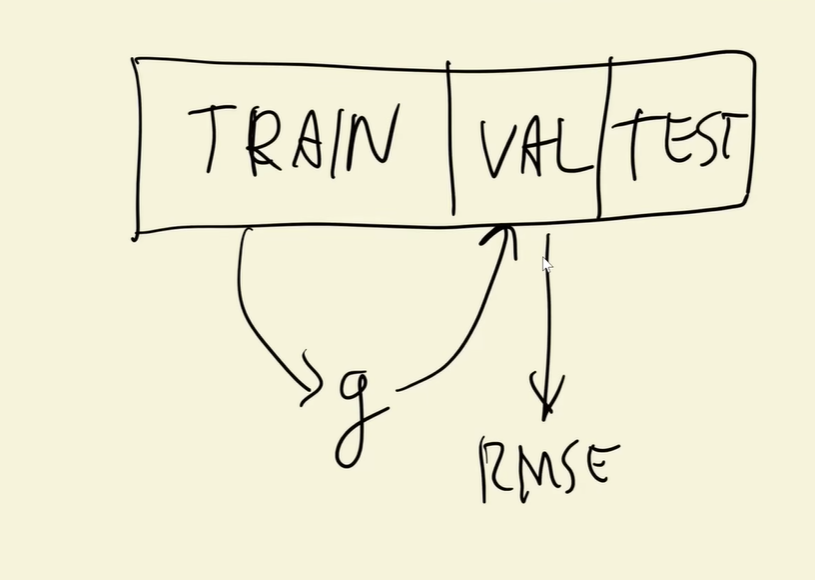

Now that we have found the best model, it's time to measure the model's final performance on the test set

Before that, it's best practice to first train a new model on the combined training + validation sets

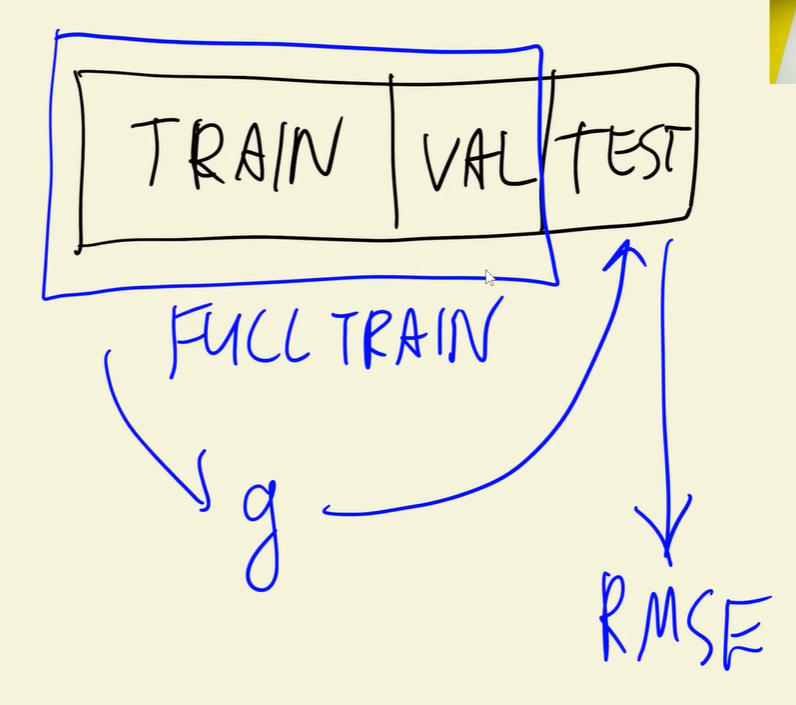

### Combine the train and validation sets

In [118]:
# Combine the training and validation features
df_full_train = pd.concat([df_train, df_val])

df_full_train = df_full_train.reset_index(drop=True)

df_full_train.shape

(9532, 15)

In [119]:
df_full_train.head(10)

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657
5,volkswagen,rabbit,2008,regular_unleaded,170.0,5.0,manual,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,29,22,873
6,bentley,continental_gtc,2013,premium_unleaded_(required),500.0,8.0,automatic,all_wheel_drive,2.0,"exotic,luxury,high-performance",midsize,convertible,24,14,520
7,bmw,6_series,2015,premium_unleaded_(required),315.0,6.0,automatic,rear_wheel_drive,2.0,"luxury,performance",midsize,coupe,32,21,3916
8,maybach,57,2012,premium_unleaded_(required),543.0,12.0,automatic,rear_wheel_drive,4.0,"exotic,luxury",large,sedan,16,10,67
9,ford,f-150_heritage,2004,regular_unleaded,202.0,6.0,manual,four_wheel_drive,2.0,NaN,large,regular_cab_pickup,18,13,5657


In [120]:
X_full_train = prepare_X(df_full_train, features)

X_full_train

array([[148.,   4.,  33., ...,   1.,   0.,   0.],
       [132.,   4.,  32., ...,   0.,   0.,   1.],
       [148.,   4.,  37., ...,   0.,   0.,   1.],
       ...,
       [332.,   8.,  23., ...,   0.,   0.,   0.],
       [148.,   4.,  34., ...,   0.,   0.,   0.],
       [290.,   6.,  25., ...,   0.,   0.,   0.]], shape=(9532, 41))

In [121]:
# Combine also the train and validation targets
y_full_train = np.concatenate([y_train, y_val])

y_full_train

array([ 9.57574708,  9.887663  ,  9.89323518, ..., 11.21756062,
        9.77542688, 10.1924563 ], shape=(9532,))

### Train the model on the full training set

In [122]:
bias, weights = train_linear_regression_with_regularization(
    X_full_train,
    y_full_train,
    r=best_r
)

print('Bias:')
print(bias)
print()
print('Weights:')
print(weights)

Bias:
7.948581528709266

Weights:
[ 0.00152501  0.11818344 -0.00666284 -0.00533588 -0.00004876 -0.09691027
 -0.79424614 -0.89250161 -0.63672632 -0.04143173  0.17556152 -0.00058254
 -0.10056164 -0.09275606 -0.46693198  0.07979639 -0.3161209  -0.55205572
 -0.07900312  0.40835373  0.23304523  0.46262769  1.96583066 -0.17698453
  0.69117834  0.59187626  0.67904809  0.60704799 -0.09705842  0.03730333
 -0.05817581 -0.02359092 -0.01192925  2.18927335  2.074904    2.05948278
 -0.05007822  0.05621476  0.18479556  0.33264539 -0.15880556]


### Final evaluation on the test set

In [123]:
X_test = prepare_X(df_test, features)

y_pred = bias + X_test.dot(weights)

rmse(y_test, y_pred)

np.float64(0.4517744943513649)

### Using the model in production environment

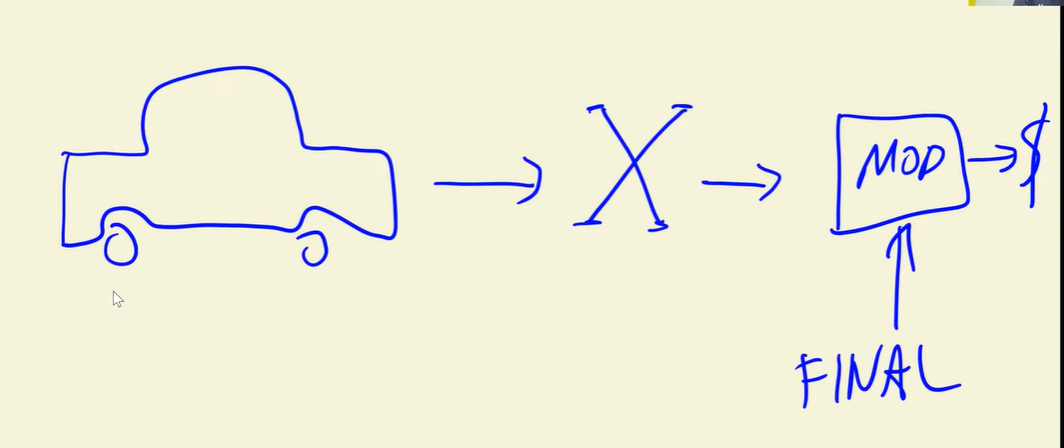

It is crucial that we use the **test set** for this because we are trying to simulate how the model will perform on unseen data 

In [124]:
df_test.iloc[20]

make                            toyota
model                           sienna
year                              2015
engine_fuel_type      regular_unleaded
engine_hp                        266.0
engine_cylinders                   6.0
transmission_type            automatic
driven_wheels        front_wheel_drive
number_of_doors                    4.0
market_category                    NaN
vehicle_size                     large
vehicle_style        passenger_minivan
highway_mpg                         25
city_mpg                            18
popularity                        2031
Name: 20, dtype: object

However, in production, these unseen instances won't be stored in a pandas DataFrame.

For example, for predicting the price of a car, the typical way to get a car instance is a user filling up a form on a website. 

That data will typically be stored in a dictionary, e.g. JSON, then sent to the model's server, and finally the model will predict a price and send it back to the user.

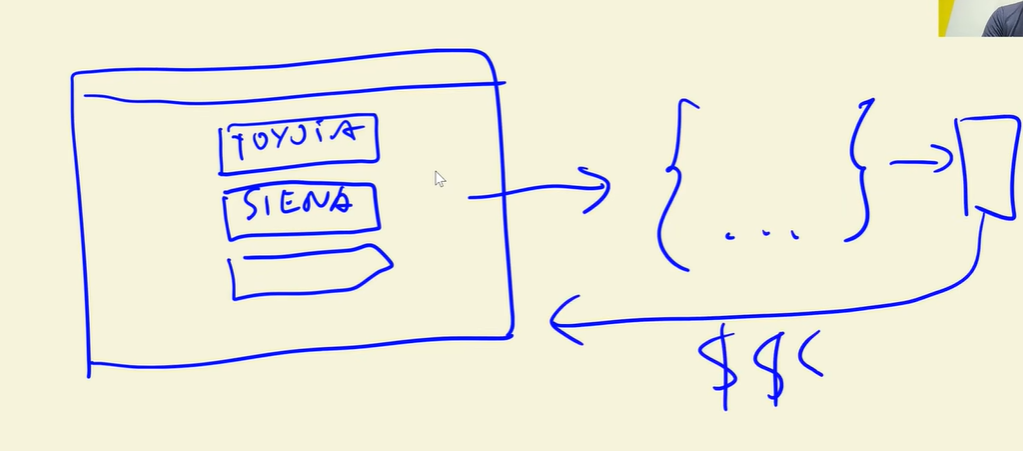

In [125]:
car = df_test.iloc[20].to_dict()
car

{'make': 'toyota',
 'model': 'sienna',
 'year': 2015,
 'engine_fuel_type': 'regular_unleaded',
 'engine_hp': 266.0,
 'engine_cylinders': 6.0,
 'transmission_type': 'automatic',
 'driven_wheels': 'front_wheel_drive',
 'number_of_doors': 4.0,
 'market_category': nan,
 'vehicle_size': 'large',
 'vehicle_style': 'passenger_minivan',
 'highway_mpg': 25,
 'city_mpg': 18,
 'popularity': 2031}

In [127]:
# Since our prepare_X() function expects a df, we need to transform the dict into one
df_single = pd.DataFrame([car])

df_single

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,toyota,sienna,2015,regular_unleaded,266.0,6.0,automatic,front_wheel_drive,4.0,NaN,large,passenger_minivan,25,18,2031


In [130]:
X_single = prepare_X(df_single, features)

X_single.shape

(1, 41)

In [ ]:
# Use the trained model on this single car
# Take note this is the log price, not in the original scale
y_pred = bias + X_single.dot(weights)
y_pred = y_pred[0]
y_pred

np.float64(10.46266099656143)

In [137]:
# Get the price in its original scale
predicted_price = np.expm1(y_pred)
print(predicted_price)

34983.52138683331


In [136]:
# Compare our prediction vs actual price
actual_price = np.expm1(y_test[20])
print(actual_price)

35000.00000000001


In [139]:
# Compute the diff
diff = actual_price - predicted_price
print(diff)

16.47861316669878
